
 # HBM O3 v3 — versión corregida con estacionalidad mensual

 ## Objetivo
 Construir, validar y ajustar un modelo jerárquico bayesiano espacio-temporal
 para O3 sobre la malla de 3 km x 3 km, usando:

 - observaciones reales de estaciones,
 - covariables derivadas del esquema A–D,
 - efecto espacial ICAR,
 - efecto temporal RW1,
 - y un efecto estacional por mes del año.

 ## Cambios principales respecto a la versión anterior
 1. Se corrigen nombres, comentarios y salidas para que todo corresponda a O3.
 2. Se mantiene la respuesta observada real de estación (`O3_obs`).
 3. Se limpian las covariables de malla para reducir colas extremas y redundancia.
 4. Se agrega un efecto estacional mensual explícito (`month_eff`) para mejorar
    la capacidad del modelo de capturar oscilaciones temporales de O3.
 5. Se conserva la validación temporal por folds:
    - 2020–2021 -> 2022
    - 2020–2022 -> 2023
    - 2020–2023 -> 2024

 ## Salidas principales
 - paneles base y paneles limpios
 - métricas por fold
 - predicciones observadas vs predichas
 - superficie final sobre toda la malla
 - diagnósticos de convergencia y muestreo

In [1]:
# %%
# ============================================================
# CELDA 1 — Configuración general
# ============================================================

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import pymc as pm
    import pytensor.tensor as pt
    import arviz as az
except Exception as e:
    raise ImportError(
        "No se pudieron importar pymc / pytensor / arviz.\n"
        "Instala en tu entorno:\n"
        "pip install pymc arviz pytensor\n\n"
        f"Detalle original: {e}"
    )

# -------------------------
# Rutas
# -------------------------
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT

OBS_CSV  = DATA_DIR / "panel_ambiental_mensual_2020_2024_coords_corregidas.csv"
GRID_CSV = DATA_DIR / "grid_3km_AD_mensual_2020_2024.csv"
W_CSV    = DATA_DIR / "W_grid_3km_queen.csv"

OUT_DIR = PROJECT_ROOT / "HBM_O3_V3_SEASON_OUT"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# Configuración del contaminante
# -------------------------
POLL = "O3"
OBS_COL = "O3"
VALID_COL = "valido_O3"

# covariables crudas del esquema A–D
X_COLS_RAW = [
    "Vel_viento_idw",
    "diff_O3_grid",
    "grad_O3_grid",
    "adv_proxy_O3_grid",
]

USE_LOG = True
EPS = 1e-6

# folds temporales
FOLDS = {
    "fold_1": {"train_years": [2020, 2021], "test_years": [2022]},
    "fold_2": {"train_years": [2020, 2021, 2022], "test_years": [2023]},
    "fold_3": {"train_years": [2020, 2021, 2022, 2023], "test_years": [2024]},
}

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR     :", DATA_DIR)
print("OUT_DIR      :", OUT_DIR)

print("\nArchivos de entrada:")
for p in [OBS_CSV, GRID_CSV, W_CSV]:
    print(" -", p.name, "| exists:", p.exists())

for p in [OBS_CSV, GRID_CSV, W_CSV]:
    if not p.exists():
        raise FileNotFoundError(f"No encuentro el archivo: {p}")

print("\nConfiguración lista.")
print("POLL       :", POLL)
print("OBS_COL    :", OBS_COL)
print("VALID_COL  :", VALID_COL)
print("X_COLS_RAW :", X_COLS_RAW)
print("USE_LOG    :", USE_LOG)

PROJECT_ROOT: d:\TRABAJO DE GRADO BEN-MAP\CODIGO
DATA_DIR     : d:\TRABAJO DE GRADO BEN-MAP\CODIGO
OUT_DIR      : d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT

Archivos de entrada:
 - panel_ambiental_mensual_2020_2024_coords_corregidas.csv | exists: True
 - grid_3km_AD_mensual_2020_2024.csv | exists: True
 - W_grid_3km_queen.csv | exists: True

Configuración lista.
POLL       : O3
OBS_COL    : O3
VALID_COL  : valido_O3
X_COLS_RAW : ['Vel_viento_idw', 'diff_O3_grid', 'grad_O3_grid', 'adv_proxy_O3_grid']
USE_LOG    : True



 # CELDA 2 — Cargar datos y construir paneles base

 ## Objetivo
 Construir:

 1. `grid_base`: panel completo celda–mes con covariables A–D.
 2. `obs_panel`: observaciones reales de estación para O3, enlazadas con:
    - `cell_id`
    - `fecha`
    - covariables de la malla
    - índices espaciales y temporales

 ## Nota
 La respuesta del HBM será siempre `O3_obs`, no `O3_idw`.

In [2]:
# %%
# ============================================================
# CELDA 2 — Cargar datos y construir paneles base
# ============================================================

obs = pd.read_csv(OBS_CSV)
grid = pd.read_csv(GRID_CSV)
w = pd.read_csv(W_CSV)

# -------------------------
# Fechas
# -------------------------
obs["fecha"] = pd.to_datetime(
    dict(year=obs["Año"].astype(int), month=obs["Mes"].astype(int), day=1),
    errors="coerce"
)
grid["fecha"] = pd.to_datetime(grid["fecha"], errors="coerce")

if obs["fecha"].isna().any():
    raise ValueError("Hay fechas inválidas en el panel de estaciones.")
if grid["fecha"].isna().any():
    raise ValueError("Hay fechas inválidas en la malla 3km.")

# -------------------------
# Validación de columnas
# -------------------------
obs_needed = ["Estacion", "cell_id", "fecha", OBS_COL, VALID_COL]
grid_needed = ["cell_id", "fecha"] + X_COLS_RAW

for c in obs_needed:
    if c not in obs.columns:
        raise ValueError(f"Falta la columna '{c}' en el panel de estaciones.")

for c in grid_needed:
    if c not in grid.columns:
        raise ValueError(f"Falta la columna '{c}' en la malla 3km.")

# -------------------------
# Filtrar observaciones válidas de O3
# -------------------------
obs[VALID_COL] = obs[VALID_COL].astype(bool)

obs_o3 = obs.loc[
    (obs[VALID_COL] == True) &
    (obs[OBS_COL].notna()) &
    (obs["cell_id"].notna())
].copy()

obs_o3 = obs_o3.rename(columns={OBS_COL: "O3_obs"})

# -------------------------
# Construir grid_base
# -------------------------
grid_base = grid[["cell_id", "fecha"] + X_COLS_RAW].copy()
grid_base["year"] = grid_base["fecha"].dt.year
grid_base["month"] = grid_base["fecha"].dt.month
grid_base["month_of_year"] = grid_base["month"] - 1

# -------------------------
# Índices globales de celda y tiempo
# -------------------------
cell_ids = np.sort(grid_base["cell_id"].unique())
time_ids = np.sort(grid_base["fecha"].unique())

cell_map = {cid: i for i, cid in enumerate(cell_ids)}
time_map = {tt: j for j, tt in enumerate(time_ids)}

grid_base["cell_idx"] = grid_base["cell_id"].map(cell_map).astype(int)
grid_base["time_idx"] = grid_base["fecha"].map(time_map).astype(int)

# -------------------------
# Unir observaciones con covariables de la malla
# -------------------------
obs_panel = obs_o3.merge(
    grid_base,
    on=["cell_id", "fecha"],
    how="left",
    validate="many_to_one"
)

missing_merge = obs_panel[X_COLS_RAW].isna().any(axis=1).sum()
if missing_merge > 0:
    raise ValueError(
        f"Hay {missing_merge} observaciones sin covariables de la malla. "
        "Revisa cell_id y fecha."
    )

obs_panel["year"] = obs_panel["fecha"].dt.year
obs_panel["month"] = obs_panel["fecha"].dt.month
obs_panel["month_of_year"] = obs_panel["month"] - 1
obs_panel["cell_idx"] = obs_panel["cell_id"].map(cell_map).astype(int)
obs_panel["time_idx"] = obs_panel["fecha"].map(time_map).astype(int)

# -------------------------
# Guardar paneles base
# -------------------------
grid_base_path = OUT_DIR / "HBM_O3_grid_base_v3.csv"
obs_panel_path = OUT_DIR / "HBM_O3_obs_panel_v3.csv"

grid_base.to_csv(grid_base_path, index=False)
obs_panel.to_csv(obs_panel_path, index=False)

print("Resumen del panel base O3")
print("- obs_panel filas         :", len(obs_panel))
print("- estaciones únicas      :", obs_panel["Estacion"].nunique())
print("- celdas con observación :", obs_panel["cell_id"].nunique())
print("- grid_base filas        :", len(grid_base))
print("- celdas totales malla   :", len(cell_ids))
print("- meses totales          :", len(time_ids))

print("\nArchivos guardados:")
print(" -", grid_base_path)
print(" -", obs_panel_path)

Resumen del panel base O3
- obs_panel filas         : 641
- estaciones únicas      : 13
- celdas con observación : 13
- grid_base filas        : 15240
- celdas totales malla   : 254
- meses totales          : 60

Archivos guardados:
 - d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT\HBM_O3_grid_base_v3.csv
 - d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT\HBM_O3_obs_panel_v3.csv




 # CELDA 3 — Preparar vecindad espacial y folds

 ## Objetivo
 Construir la estructura espacial del modelo:

 - pares únicos no dirigidos para la penalización ICAR
 - definición de folds temporales

In [3]:
# %%
# ============================================================
# CELDA 3 — Vecindad espacial y folds
# ============================================================

if not {"cell_id", "neighbor_id"}.issubset(w.columns):
    raise ValueError("W_grid_3km_queen.csv debe tener las columnas 'cell_id' y 'neighbor_id'.")

w_use = w[
    w["cell_id"].isin(cell_ids) &
    w["neighbor_id"].isin(cell_ids)
].copy()

if len(w_use) == 0:
    raise ValueError("La vecindad quedó vacía después de filtrar por celdas de la malla.")

w_use["i"] = w_use["cell_id"].map(cell_map)
w_use["j"] = w_use["neighbor_id"].map(cell_map)

if w_use["i"].isna().any() or w_use["j"].isna().any():
    raise ValueError("Hay relaciones de vecindad que no pudieron mapearse a índices internos.")

w_use["i"] = w_use["i"].astype(int)
w_use["j"] = w_use["j"].astype(int)

# quitar lazos propios
w_use = w_use.loc[w_use["i"] != w_use["j"]].copy()

# dejar pares únicos no dirigidos
ii = np.minimum(w_use["i"].values, w_use["j"].values)
jj = np.maximum(w_use["i"].values, w_use["j"].values)

pairs = np.unique(np.column_stack([ii, jj]), axis=0)
w_edges = pd.DataFrame(pairs, columns=["i", "j"])

w_edges_path = OUT_DIR / "HBM_O3_W_edges_queen_v3.csv"
w_edges.to_csv(w_edges_path, index=False)

folds_path = OUT_DIR / "HBM_O3_folds_v3.json"
with open(folds_path, "w", encoding="utf-8") as f:
    json.dump(FOLDS, f, ensure_ascii=False, indent=2)

print("Resumen CELDA 3")
print("- relaciones originales en W     :", len(w))
print("- relaciones válidas tras filtro :", len(w_use))
print("- edges únicos no dirigidos      :", len(w_edges))
print("- nodos únicos en W              :", len(set(w_use["i"]).union(set(w_use["j"]))))

print("\nArchivos guardados:")
print("-", w_edges_path)
print("-", folds_path)

Resumen CELDA 3
- relaciones originales en W     : 1610
- relaciones válidas tras filtro : 1610
- edges únicos no dirigidos      : 805
- nodos únicos en W              : 254

Archivos guardados:
- d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT\HBM_O3_W_edges_queen_v3.csv
- d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT\HBM_O3_folds_v3.json




 # CELDA 4 — Auditoría del panel observado O3

 ## Objetivo
 Revisar:
 - duplicados por estación-mes,
 - distribución por estación,
 - observaciones atípicas usando IQR.

 ## Nota
 Esta celda no elimina datos; solo audita.

In [4]:
# %%
# ============================================================
# CELDA 4 — Auditoría de calidad del panel observado O3
# ============================================================

obs_audit = pd.read_csv(OBS_CSV)

obs_audit["fecha"] = pd.to_datetime(
    dict(year=obs_audit["Año"].astype(int), month=obs_audit["Mes"].astype(int), day=1),
    errors="coerce"
)

if obs_audit["fecha"].isna().any():
    raise ValueError("Hay fechas inválidas en el panel observado.")

obs_audit["valido_O3"] = obs_audit["valido_O3"].astype(bool)

o3_obs = obs_audit.loc[
    (obs_audit["valido_O3"] == True) &
    (obs_audit["O3"].notna())
].copy()

o3_obs = o3_obs.rename(columns={"O3": "O3_obs"})

print("Resumen general del panel observado O3")
print("- filas totales en archivo :", len(obs_audit))
print("- filas válidas O3         :", len(o3_obs))
print("- estaciones con O3 válido :", o3_obs["Estacion"].nunique())
print("- meses observados O3      :", o3_obs["fecha"].nunique())
print("- rango temporal           :", o3_obs["fecha"].min().date(), "a", o3_obs["fecha"].max().date())

# duplicados
dup_mask = o3_obs.duplicated(subset=["Estacion", "fecha"], keep=False)
dup_rows = o3_obs.loc[dup_mask].sort_values(["Estacion", "fecha"]).copy()

print("\nDuplicados por estación-mes:")
print("- número de filas duplicadas        :", len(dup_rows))
print("- combinaciones duplicadas únicas   :", dup_rows[["Estacion", "fecha"]].drop_duplicates().shape[0])

# resumen por estación
station_summary = (
    o3_obs.groupby("Estacion")["O3_obs"]
    .agg(
        n="count",
        mean="mean",
        std="std",
        min="min",
        q01=lambda s: s.quantile(0.01),
        q05=lambda s: s.quantile(0.05),
        q25=lambda s: s.quantile(0.25),
        median="median",
        q75=lambda s: s.quantile(0.75),
        q95=lambda s: s.quantile(0.95),
        q99=lambda s: s.quantile(0.99),
        max="max",
    )
    .reset_index()
    .sort_values("mean", ascending=False)
)

# IQR por estación
bounds = (
    o3_obs.groupby("Estacion")["O3_obs"]
    .agg(
        q1=lambda s: s.quantile(0.25),
        q3=lambda s: s.quantile(0.75)
    )
    .reset_index()
)
bounds["iqr"] = bounds["q3"] - bounds["q1"]
bounds["lower_iqr15"] = bounds["q1"] - 1.5 * bounds["iqr"]
bounds["upper_iqr15"] = bounds["q3"] + 1.5 * bounds["iqr"]

o3_obs = o3_obs.merge(bounds, on="Estacion", how="left")
o3_obs["flag_iqr15"] = (
    (o3_obs["O3_obs"] < o3_obs["lower_iqr15"]) |
    (o3_obs["O3_obs"] > o3_obs["upper_iqr15"])
)

flagged_rows = o3_obs.loc[
    o3_obs["flag_iqr15"] == True,
    ["Estacion", "fecha", "Año", "Mes", "O3_obs", "q1", "q3", "iqr", "lower_iqr15", "upper_iqr15"]
].sort_values(["Estacion", "fecha"])

station_summary_path = OUT_DIR / "HBM_O3_obs_audit_station_summary.csv"
duplicates_path = OUT_DIR / "HBM_O3_obs_audit_duplicates.csv"
flagged_rows_path = OUT_DIR / "HBM_O3_obs_audit_flagged_rows.csv"

station_summary.to_csv(station_summary_path, index=False)
dup_rows.to_csv(duplicates_path, index=False)
flagged_rows.to_csv(flagged_rows_path, index=False)

print("\nResumen por estación:")
display(station_summary)

print("\nPrimeras observaciones sospechosas:")
display(flagged_rows.head(20))

Resumen general del panel observado O3
- filas totales en archivo : 862
- filas válidas O3         : 641
- estaciones con O3 válido : 13
- meses observados O3      : 60
- rango temporal           : 2020-01-01 a 2024-12-01

Duplicados por estación-mes:
- número de filas duplicadas        : 0
- combinaciones duplicadas únicas   : 0

Resumen por estación:


,Estacion,n,mean,std,min,q01,q05,q25,median,q75,q95,q99,max
12,Usaquen,51,17.937328,4.283682,11.055108,11.158857,12.153578,14.928425,17.752492,20.739756,24.240819,27.763404,29.473617
3,Fontibon,48,16.459771,4.608458,7.668927,7.794597,9.571037,13.975386,16.297133,18.557883,24.961024,28.953072,30.480650
5,Kennedy,47,15.202748,4.898863,5.461821,5.478597,6.662224,12.121556,14.886197,18.922981,21.672908,25.866897,29.263366
11,Tunal,54,14.048399,3.494724,8.308227,8.491760,8.838025,11.497216,13.896803,16.559136,19.506059,21.793331,23.465912
1,Centro de Alto Rendimiento,52,14.035078,4.393337,7.404240,7.594264,8.204113,11.580287,13.117854,15.792641,20.210945,28.971717,30.935177
7,MinAmbiente,42,13.846842,3.923727,7.355540,7.361674,7.810999,11.136097,13.475283,17.204467,20.688696,21.326248,21.688210
6,Las Ferias,58,13.173022,3.401223,7.158400,7.264181,8.843822,10.607936,12.879289,14.562837,19.715336,23.090518,25.389185
10,Suba,55,12.564030,3.845955,6.512940,6.588514,6.869007,9.847548,12.789083,14.064412,18.305968,23.614369,26.820282
4,Guaymaral,55,12.000670,3.563216,3.573851,5.310641,7.320790,9.763073,11.961096,13.746040,17.717862,22.211151,26.142073
9,San Cristobal,50,11.495471,4.033298,2.956871,3.474486,4.884314,8.914462,11.822432,14.006287,18.046626,20.812146,21.282764



Primeras observaciones sospechosas:


,Estacion,fecha,Año,Mes,O3_obs,q1,q3,iqr,lower_iqr15,upper_iqr15
19,Centro de Alto Rendimiento,2020-03-01,2020,3,30.935177,11.580287,15.792641,4.212354,5.261757,22.111172
29,Centro de Alto Rendimiento,2020-04-01,2020,4,27.085255,11.580287,15.792641,4.212354,5.261757,22.111172
20,Fontibon,2020-03-01,2020,3,27.230484,13.975386,18.557883,4.582497,7.101640,25.431629
411,Fontibon,2023-03-01,2023,3,30.480650,13.975386,18.557883,4.582497,7.101640,25.431629
21,Guaymaral,2020-03-01,2020,3,26.142073,9.763073,13.746040,3.982968,3.788621,19.720492
559,Guaymaral,2024-05-01,2024,5,3.573851,9.763073,13.746040,3.982968,3.788621,19.720492
22,Kennedy,2020-03-01,2020,3,29.263366,12.121556,18.922981,6.801425,1.919418,29.125119
23,Las Ferias,2020-03-01,2020,3,21.356436,10.607936,14.562837,3.954901,4.675585,20.495188
606,Las Ferias,2024-09-01,2024,9,25.389185,10.607936,14.562837,3.954901,4.675585,20.495188
25,Puente Aranda,2020-03-01,2020,3,16.402266,6.750071,10.387323,3.637252,1.294193,15.843200




 # CELDA 5 — Auditoría de covariables de malla O3

 ## Objetivo
 Revisar:
 - rangos,
 - nulos,
 - extremos,
 - correlación entre covariables.

In [5]:
# %%
# ============================================================
# CELDA 5 — Auditoría de covariables de malla O3
# ============================================================

grid_audit = pd.read_csv(GRID_CSV)
grid_audit["fecha"] = pd.to_datetime(grid_audit["fecha"], errors="coerce")

if grid_audit["fecha"].isna().any():
    raise ValueError("Hay fechas inválidas en la malla A–D.")

covars_O3 = [
    "Vel_viento_idw",
    "diff_O3_grid",
    "grad_O3_grid",
    "adv_proxy_O3_grid",
]

missing_cols = [c for c in covars_O3 if c not in grid_audit.columns]
if missing_cols:
    raise ValueError(f"Faltan columnas en la malla: {missing_cols}")

desc_rows = []
for col in covars_O3:
    s = pd.to_numeric(grid_audit[col], errors="coerce")
    desc_rows.append({
        "variable": col,
        "n": int(s.notna().sum()),
        "n_null": int(s.isna().sum()),
        "mean": float(np.nanmean(s)),
        "std": float(np.nanstd(s, ddof=1)),
        "min": float(np.nanmin(s)),
        "q01": float(np.nanquantile(s, 0.01)),
        "q05": float(np.nanquantile(s, 0.05)),
        "q25": float(np.nanquantile(s, 0.25)),
        "median": float(np.nanquantile(s, 0.50)),
        "q75": float(np.nanquantile(s, 0.75)),
        "q95": float(np.nanquantile(s, 0.95)),
        "q99": float(np.nanquantile(s, 0.99)),
        "max": float(np.nanmax(s)),
    })

desc_covars = pd.DataFrame(desc_rows)
corr_covars = grid_audit[covars_O3].corr(numeric_only=True)

desc_covars_path = OUT_DIR / "HBM_O3_grid_audit_covariate_summary.csv"
corr_covars_path = OUT_DIR / "HBM_O3_grid_audit_correlation.csv"

desc_covars.to_csv(desc_covars_path, index=False)
corr_covars.to_csv(corr_covars_path)

print("Resumen descriptivo de covariables:")
display(desc_covars)

print("\nCorrelación entre covariables:")
display(corr_covars)

Resumen descriptivo de covariables:


,variable,n,n_null,mean,std,min,q01,q05,q25,median,q75,q95,q99,max
0,Vel_viento_idw,15240,0,1.116795e+00,0.221991,5.046784e-01,8.076667e-01,0.869237,0.944333,1.061290,1.215806,1.591290,1.717742,1.717742
1,diff_O3_grid,15240,0,-6.381597e-18,3.219685,-4.777906e+01,-1.098203e+01,-2.031814,-0.096547,-0.000173,0.043480,2.075238,11.248877,40.731980
2,grad_O3_grid,15240,0,7.861081e-05,0.000148,1.124893e-08,4.822032e-07,0.000001,0.000004,0.000015,0.000082,0.000372,0.000724,0.001661
3,adv_proxy_O3_grid,15240,0,8.641958e-05,0.000162,1.280564e-08,5.156865e-07,0.000001,0.000005,0.000016,0.000091,0.000422,0.000784,0.001855



Correlación entre covariables:


,Vel_viento_idw,diff_O3_grid,grad_O3_grid,adv_proxy_O3_grid
Vel_viento_idw,1.000000,0.002780,-0.041792,0.058157
diff_O3_grid,0.002780,1.000000,0.036013,0.038851
grad_O3_grid,-0.041792,0.036013,1.000000,0.978705
adv_proxy_O3_grid,0.058157,0.038851,0.978705,1.000000



 # CELDA 6 — Construcción de covariables limpias para O3

 ## Estrategia
 - `Vel_viento_idw`: se conserva
 - `diff_O3_grid`: signed-log + winsorización
 - `grad_O3_grid`: se conserva solo para auditoría, no entra al modelo final
 - `adv_proxy_O3_grid`: winsorización

 ## Covariables limpias finales
 - `Vel_viento_idw_clean`
 - `diff_O3_grid_slog_clean`
 - `adv_proxy_O3_grid_clean`

In [6]:
# %%
# ============================================================
# CELDA 6 — Construcción de covariables limpias O3
# ============================================================

grid_clean = grid_audit.copy()

def winsorize_series(s, q_low=0.01, q_high=0.99):
    s = pd.to_numeric(s, errors="coerce").astype(float)
    lo = s.quantile(q_low)
    hi = s.quantile(q_high)
    return s.clip(lower=lo, upper=hi), lo, hi

transform_report = []

# velocidad del viento
grid_clean["Vel_viento_idw_clean"] = pd.to_numeric(
    grid_clean["Vel_viento_idw"], errors="coerce"
).astype(float)

transform_report.append({
    "variable_original": "Vel_viento_idw",
    "variable_limpia": "Vel_viento_idw_clean",
    "transformacion": "sin cambio",
    "q_low": np.nan,
    "q_high": np.nan,
})

# diff O3 -> signed-log + winsor
x_diff = pd.to_numeric(grid_clean["diff_O3_grid"], errors="coerce").astype(float)
grid_clean["diff_O3_grid_slog"] = np.sign(x_diff) * np.log1p(np.abs(x_diff))

grid_clean["diff_O3_grid_slog_clean"], lo_diff, hi_diff = winsorize_series(
    grid_clean["diff_O3_grid_slog"], q_low=0.01, q_high=0.99
)

transform_report.append({
    "variable_original": "diff_O3_grid",
    "variable_limpia": "diff_O3_grid_slog_clean",
    "transformacion": "signed_log1p + winsor_1_99",
    "q_low": float(lo_diff),
    "q_high": float(hi_diff),
})

# grad O3 -> respaldo / auditoría
grid_clean["grad_O3_grid_clean"], lo_grad, hi_grad = winsorize_series(
    grid_clean["grad_O3_grid"], q_low=0.01, q_high=0.99
)

transform_report.append({
    "variable_original": "grad_O3_grid",
    "variable_limpia": "grad_O3_grid_clean",
    "transformacion": "winsor_1_99",
    "q_low": float(lo_grad),
    "q_high": float(hi_grad),
})

# adv O3 -> winsor
grid_clean["adv_proxy_O3_grid_clean"], lo_adv, hi_adv = winsorize_series(
    grid_clean["adv_proxy_O3_grid"], q_low=0.01, q_high=0.99
)

transform_report.append({
    "variable_original": "adv_proxy_O3_grid",
    "variable_limpia": "adv_proxy_O3_grid_clean",
    "transformacion": "winsor_1_99",
    "q_low": float(lo_adv),
    "q_high": float(hi_adv),
})

transform_report_df = pd.DataFrame(transform_report)

X_COLS_O3_CLEAN = [
    "Vel_viento_idw_clean",
    "diff_O3_grid_slog_clean",
    "adv_proxy_O3_grid_clean",
]

grid_clean_path = OUT_DIR / "HBM_O3_grid_clean_v3.csv"
transform_report_path = OUT_DIR / "HBM_O3_grid_clean_transform_report_v3.csv"
xcols_clean_path = OUT_DIR / "HBM_O3_clean_xcols_v3.json"

grid_clean.to_csv(grid_clean_path, index=False)
transform_report_df.to_csv(transform_report_path, index=False)

with open(xcols_clean_path, "w", encoding="utf-8") as f:
    json.dump(X_COLS_O3_CLEAN, f, ensure_ascii=False, indent=2)

print("Covariables limpias construidas.")
print("Covariables finales del modelo:", X_COLS_O3_CLEAN)

display(transform_report_df)

Covariables limpias construidas.
Covariables finales del modelo: ['Vel_viento_idw_clean', 'diff_O3_grid_slog_clean', 'adv_proxy_O3_grid_clean']


,variable_original,variable_limpia,transformacion,q_low,q_high
0,Vel_viento_idw,Vel_viento_idw_clean,sin cambio,NaN,NaN
1,diff_O3_grid,diff_O3_grid_slog_clean,signed_log1p + winsor_1_99,-2.483408e+00,2.505432
2,grad_O3_grid,grad_O3_grid_clean,winsor_1_99,4.822032e-07,0.000724
3,adv_proxy_O3_grid,adv_proxy_O3_grid_clean,winsor_1_99,5.156865e-07,0.000784



 # CELDA 7 — Reconstrucción del panel HBM con covariables limpias

 ## Objetivo
 Construir:
 - `grid_base_clean`
 - `obs_panel_clean`

 usando la versión limpia de las covariables para O3.

In [7]:
# %%
# ============================================================
# CELDA 7 — Reconstruir panel HBM con covariables limpias
# ============================================================

required_clean_cols = [
    "cell_id", "fecha",
    "Vel_viento_idw_clean",
    "diff_O3_grid_slog_clean",
    "adv_proxy_O3_grid_clean",
]

missing_clean = [c for c in required_clean_cols if c not in grid_clean.columns]
if missing_clean:
    raise ValueError(f"Faltan columnas en grid_clean: {missing_clean}")

grid_clean["fecha"] = pd.to_datetime(grid_clean["fecha"], errors="coerce")
if grid_clean["fecha"].isna().any():
    raise ValueError("Hay fechas inválidas en grid_clean.")

grid_clean["year"] = grid_clean["fecha"].dt.year
grid_clean["month"] = grid_clean["fecha"].dt.month
grid_clean["month_of_year"] = grid_clean["month"] - 1

grid_base_clean = grid_clean[
    ["cell_id", "fecha", "year", "month", "month_of_year"] + X_COLS_O3_CLEAN
].copy()

grid_base_clean["cell_idx"] = grid_base_clean["cell_id"].map(cell_map)
grid_base_clean["time_idx"] = grid_base_clean["fecha"].map(time_map)

if grid_base_clean["cell_idx"].isna().any():
    raise ValueError("Hay cell_id en la malla limpia que no pudieron mapearse.")
if grid_base_clean["time_idx"].isna().any():
    raise ValueError("Hay fechas en la malla limpia que no pudieron mapearse.")

grid_base_clean["cell_idx"] = grid_base_clean["cell_idx"].astype(int)
grid_base_clean["time_idx"] = grid_base_clean["time_idx"].astype(int)

# reconstruir observaciones válidas
obs_clean_src = pd.read_csv(OBS_CSV)
obs_clean_src["fecha"] = pd.to_datetime(
    dict(year=obs_clean_src["Año"].astype(int), month=obs_clean_src["Mes"].astype(int), day=1),
    errors="coerce"
)

obs_clean_src["valido_O3"] = obs_clean_src["valido_O3"].astype(bool)

obs_o3_clean = obs_clean_src.loc[
    (obs_clean_src["valido_O3"] == True) &
    (obs_clean_src["O3"].notna()) &
    (obs_clean_src["cell_id"].notna())
].copy()

obs_o3_clean = obs_o3_clean.rename(columns={"O3": "O3_obs"})

obs_panel_clean = obs_o3_clean.merge(
    grid_base_clean,
    on=["cell_id", "fecha"],
    how="left",
    validate="many_to_one"
)

missing_covs_clean = obs_panel_clean[X_COLS_O3_CLEAN].isna().any(axis=1).sum()
if missing_covs_clean > 0:
    raise ValueError(
        f"Hay {missing_covs_clean} observaciones sin covariables limpias. "
        "Revisa cell_id y fecha."
    )

grid_base_clean_path = OUT_DIR / "HBM_O3_grid_base_clean_v3.csv"
obs_panel_clean_path = OUT_DIR / "HBM_O3_obs_panel_clean_v3.csv"

grid_base_clean.to_csv(grid_base_clean_path, index=False)
obs_panel_clean.to_csv(obs_panel_clean_path, index=False)

print("Panel HBM limpio reconstruido correctamente.\n")
print("grid_base_clean filas:", len(grid_base_clean))
print("obs_panel_clean filas:", len(obs_panel_clean))
print("estaciones únicas    :", obs_panel_clean["Estacion"].nunique())
print("celdas observadas    :", obs_panel_clean["cell_id"].nunique())

display(
    obs_panel_clean[
        ["Estacion", "fecha", "O3_obs", "cell_id"] + X_COLS_O3_CLEAN
    ].head()
)

Panel HBM limpio reconstruido correctamente.

grid_base_clean filas: 15240
obs_panel_clean filas: 641
estaciones únicas    : 13
celdas observadas    : 13


,Estacion,fecha,O3_obs,cell_id,Vel_viento_idw_clean,diff_O3_grid_slog_clean,adv_proxy_O3_grid_clean
0,Centro de Alto Rendimiento,2020-01-01,17.690691,567,1.503226,-2.483408,0.000784
1,Fontibon,2020-01-01,15.080595,485,1.503226,1.642261,0.000506
2,Guaymaral,2020-01-01,13.813510,653,1.128177,0.806332,0.000053
3,Kennedy,2020-01-01,21.176695,442,1.503226,-2.223039,0.000735
4,Las Ferias,2020-01-01,11.864831,568,1.497067,2.505432,0.000743


 # CELDA 8 — Funciones auxiliares

 ## Objetivo
 Definir funciones reutilizables para:
 - escalar covariables usando solo train,
 - llevar covariables escaladas al panel observado,
 - calcular métricas puntuales y probabilísticas,
 - obtener percentiles posteriores en escala original.

 ## Nota metodológica
 El escalamiento se hace usando únicamente los años de entrenamiento,
 para evitar fuga de información hacia los folds de prueba.

In [14]:
# %%
# ============================================================
# CELDA 8 — Funciones auxiliares
# ============================================================

def scale_grid_by_train_years(grid_df, x_cols, train_years):
    """
    Estandariza covariables usando solo filas del grid pertenecientes
    a los años de entrenamiento.
    """
    grid_scaled = grid_df.copy()
    params = {}

    train_mask = grid_scaled["year"].isin(train_years)

    for col in x_cols:
        mu = grid_scaled.loc[train_mask, col].mean()
        sd = grid_scaled.loc[train_mask, col].std(ddof=0)

        if pd.isna(sd) or sd == 0:
            sd = 1.0

        z_col = f"{col}_z"
        grid_scaled[z_col] = (grid_scaled[col] - mu) / sd
        params[col] = {"mu": float(mu), "sd": float(sd)}

    return grid_scaled, params


def merge_scaled_covariates_to_obs(obs_df, grid_scaled, x_cols):
    """
    Lleva covariables escaladas desde la malla al panel observado
    usando la llave (cell_id, fecha).
    """
    z_cols = [f"{c}_z" for c in x_cols]

    out = obs_df.drop(columns=x_cols, errors="ignore").merge(
        grid_scaled[["cell_id", "fecha"] + z_cols],
        on=["cell_id", "fecha"],
        how="left",
        validate="many_to_one"
    )

    missing = out[z_cols].isna().any(axis=1).sum()
    if missing > 0:
        raise ValueError(f"Hay {missing} observaciones sin covariables escaladas.")

    return out


def interval_metrics(y_true, p05, p50, p95, alpha=0.10):
    """
    Calcula métricas puntuales y probabilísticas
    para un intervalo central del 90%.
    """
    y_true = np.asarray(y_true, dtype=float)
    p05 = np.asarray(p05, dtype=float)
    p50 = np.asarray(p50, dtype=float)
    p95 = np.asarray(p95, dtype=float)

    m = ~np.isnan(y_true) & ~np.isnan(p05) & ~np.isnan(p50) & ~np.isnan(p95)
    y_true = y_true[m]
    p05 = p05[m]
    p50 = p50[m]
    p95 = p95[m]

    if len(y_true) == 0:
        return {
            "n": 0,
            "mae": np.nan,
            "rmse": np.nan,
            "bias": np.nan,
            "r": np.nan,
            "r2": np.nan,
            "coverage_90": np.nan,
            "width_90_mean": np.nan,
            "wis_90": np.nan,
        }

    err = p50 - y_true
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err**2))
    bias = np.mean(err)

    if np.std(y_true) == 0 or np.std(p50) == 0:
        r = np.nan
        r2 = np.nan
    else:
        r = np.corrcoef(y_true, p50)[0, 1]
        r2 = r**2

    coverage = np.mean((y_true >= p05) & (y_true <= p95))
    width = np.mean(p95 - p05)

    wis = np.mean(
        (p95 - p05)
        + (2 / alpha) * (p05 - y_true) * (y_true < p05)
        + (2 / alpha) * (y_true - p95) * (y_true > p95)
    )

    return {
        "n": int(len(y_true)),
        "mae": float(mae),
        "rmse": float(rmse),
        "bias": float(bias),
        "r": float(r) if not np.isnan(r) else np.nan,
        "r2": float(r2) if not np.isnan(r2) else np.nan,
        "coverage_90": float(coverage),
        "width_90_mean": float(width),
        "wis_90": float(wis),
    }


def posterior_predict_concentration_season(
    idata,
    X_mat,
    cell_idx_arr,
    time_idx_arr,
    month_idx_arr,
    eps=1e-6
):
    """
    Obtiene p05, p50 y p95 de la concentración en escala original,
    incorporando efecto espacial, temporal y estacional.
    """
    alpha_s = idata.posterior["alpha"].values.reshape(-1)
    beta_s = idata.posterior["beta"].values.reshape(
        -1, idata.posterior["beta"].values.shape[-1]
    )
    phi_s = idata.posterior["phi"].values.reshape(
        -1, idata.posterior["phi"].values.shape[-1]
    )
    delta_s = idata.posterior["delta"].values.reshape(
        -1, idata.posterior["delta"].values.shape[-1]
    )
    month_eff_s = idata.posterior["month_eff"].values.reshape(
        -1, idata.posterior["month_eff"].values.shape[-1]
    )

    mu_s = (
        alpha_s[:, None]
        + (beta_s @ X_mat.T)
        + phi_s[:, cell_idx_arr]
        + delta_s[:, time_idx_arr]
        + month_eff_s[:, month_idx_arr]
    )

    c_s = np.exp(mu_s) - eps

    p05 = np.quantile(c_s, 0.05, axis=0)
    p50 = np.quantile(c_s, 0.50, axis=0)
    p95 = np.quantile(c_s, 0.95, axis=0)

    return p05, p50, p95


print("CELDA 8 cargada correctamente.")

CELDA 8 cargada correctamente.


 # CELDA 9 — Definición del modelo season

 ## Objetivo
 Definir la función que ajusta el HBM de O3 con:
 - efecto espacial ICAR,
 - efecto temporal RW1,
 - efecto estacional mensual explícito.

 ## Forma general
 log(O3_obs) = alpha + X beta + phi_i + delta_t + month_eff_m + error

 donde:
 - `phi_i` es el efecto espacial estructurado,
 - `delta_t` es el efecto temporal global,
 - `month_eff_m` captura la estacionalidad intra-anual de O3.

In [ ]:
# %%
# ============================================================
# CELDA 9 — Modelo HBM season
# ============================================================

def fit_hbm_season_fold(
    obs_scaled,
    grid_scaled,
    w_edges_df,
    x_cols_raw,
    train_years,
    test_years,
    n_cells,
    n_times,
    draws=1000,
    tune=1500,
    chains=4,
    target_accept=0.99,
    max_treedepth=15,
    random_seed=42,
):
    z_cols = [f"{c}_z" for c in x_cols_raw]

    train_mask_obs = obs_scaled["year"].isin(train_years)
    test_mask_obs = obs_scaled["year"].isin(test_years)

    train_obs = obs_scaled.loc[train_mask_obs].copy()
    test_obs = obs_scaled.loc[test_mask_obs].copy()

    if len(train_obs) == 0:
        raise ValueError("No hay observaciones de entrenamiento para este fold.")
    if len(test_obs) == 0:
        raise ValueError("No hay observaciones de prueba para este fold.")

    # -------------------------
    # Datos train
    # -------------------------
    X_train = train_obs[z_cols].to_numpy(dtype=float)
    y_train_raw = train_obs["O3_obs"].to_numpy(dtype=float)
    y_train = np.log(y_train_raw + EPS) if USE_LOG else y_train_raw

    cell_train = train_obs["cell_idx"].to_numpy(dtype=int)
    time_train = train_obs["time_idx"].to_numpy(dtype=int)
    month_train = train_obs["month_of_year"].to_numpy(dtype=int)

    # -------------------------
    # Datos test
    # -------------------------
    X_test = test_obs[z_cols].to_numpy(dtype=float)
    cell_test = test_obs["cell_idx"].to_numpy(dtype=int)
    time_test = test_obs["time_idx"].to_numpy(dtype=int)
    month_test = test_obs["month_of_year"].to_numpy(dtype=int)

    # -------------------------
    # Vecindad espacial
    # -------------------------
    ei = w_edges_df["i"].to_numpy(dtype=int)
    ej = w_edges_df["j"].to_numpy(dtype=int)

    p = X_train.shape[1]
    alpha_mu = float(np.mean(y_train))

    with pm.Model() as model:
        # Efectos fijos
        alpha = pm.Normal("alpha", mu=alpha_mu, sigma=1.0)
        beta = pm.Normal("beta", mu=0.0, sigma=0.5, shape=p)

        # Error observacional
        sigma_y = pm.HalfNormal("sigma_y", sigma=0.75)

        # Efecto espacial ICAR
        tau_phi = pm.Exponential("tau_phi", 2.0)
        phi_raw = pm.Normal("phi_raw", mu=0.0, sigma=1.0, shape=n_cells)
        phi = pm.Deterministic("phi", phi_raw - pt.mean(phi_raw))

        pm.Potential(
            "icar_penalty",
            -0.5 * tau_phi * pt.sum((phi[ei] - phi[ej]) ** 2)
        )

        # Efecto temporal RW1
        sigma_t = pm.HalfNormal("sigma_t", sigma=0.25)
        delta_raw = pm.GaussianRandomWalk("delta_raw", sigma=sigma_t, shape=n_times)
        delta = pm.Deterministic("delta", delta_raw - pt.mean(delta_raw))

        # Efecto estacional mensual
        sigma_month = pm.HalfNormal("sigma_month", sigma=0.5)
        month_raw = pm.Normal("month_raw", mu=0.0, sigma=1.0, shape=12)
        month_eff = pm.Deterministic(
            "month_eff",
            sigma_month * (month_raw - pt.mean(month_raw))
        )

        # Media del modelo
        mu_train = (
            alpha
            + pt.dot(X_train, beta)
            + phi[cell_train]
            + delta[time_train]
            + month_eff[month_train]
        )

        # Verosimilitud
        pm.Normal("y_obs", mu=mu_train, sigma=sigma_y, observed=y_train)

        # Muestreo
        idata = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            init="adapt_diag",
            target_accept=target_accept,
            max_treedepth=max_treedepth,
            random_seed=random_seed,
            return_inferencedata=True,
            progressbar=True,
        )

    # -------------------------
    # Predicción test
    # -------------------------
    p05_test, p50_test, p95_test = posterior_predict_concentration_season(
        idata=idata,
        X_mat=X_test,
        cell_idx_arr=cell_test,
        time_idx_arr=time_test,
        month_idx_arr=month_test,
        eps=EPS
    )

    test_pred = test_obs[
        ["Estacion", "fecha", "year", "month", "month_of_year",
         "cell_id", "cell_idx", "time_idx", "O3_obs"]
    ].copy()

    test_pred["p05_hbm"] = p05_test
    test_pred["p50_hbm"] = p50_test
    test_pred["p95_hbm"] = p95_test
    test_pred["width_90"] = test_pred["p95_hbm"] - test_pred["p05_hbm"]

    met = interval_metrics(
        y_true=test_pred["O3_obs"].values,
        p05=test_pred["p05_hbm"].values,
        p50=test_pred["p50_hbm"].values,
        p95=test_pred["p95_hbm"].values,
        alpha=0.10
    )

    return idata, test_pred, met


print("CELDA 9 cargada correctamente.")

CELDA 9 cargada correctamente.


 
 # CELDA 10 — Validación temporal del modelo season

 ## Objetivo
 Ejecutar la validación temporal del HBM de O3 con estacionalidad mensual
 usando los 3 folds definidos.

 ## Salidas principales
 - métricas por fold,
 - predicciones observadas vs predichas,
 - summaries del posterior,
 - parámetros de escalamiento.

In [16]:
# %%
# ============================================================
# CELDA 10 — Validación temporal season
# ============================================================

all_metrics_season = []
all_test_preds_season = []

DRAWS_S = 1000
TUNE_S = 1500
CHAINS_S = 4
TARGET_ACCEPT_S = 0.99
MAX_TREEDEPTH_S = 15
RANDOM_SEED_S = 42

for fold_name, fold_info in FOLDS.items():
    print("\n" + "=" * 80)
    print(f"Corriendo season - {fold_name}")
    print("Train years:", fold_info["train_years"])
    print("Test years :", fold_info["test_years"])

    # 1) Escalar covariables limpias usando solo train
    grid_scaled_s, scale_params_s = scale_grid_by_train_years(
        grid_df=grid_base_clean,
        x_cols=X_COLS_O3_CLEAN,
        train_years=fold_info["train_years"]
    )

    # 2) Llevar covariables escaladas al panel observado limpio
    obs_scaled_s = merge_scaled_covariates_to_obs(
        obs_df=obs_panel_clean,
        grid_scaled=grid_scaled_s,
        x_cols=X_COLS_O3_CLEAN
    )

    # 3) Ajustar modelo del fold
    idata_fold_s, test_pred_fold_s, met_fold_s = fit_hbm_season_fold(
        obs_scaled=obs_scaled_s,
        grid_scaled=grid_scaled_s,
        w_edges_df=w_edges,
        x_cols_raw=X_COLS_O3_CLEAN,
        train_years=fold_info["train_years"],
        test_years=fold_info["test_years"],
        n_cells=len(cell_ids),
        n_times=len(time_ids),
        draws=DRAWS_S,
        tune=TUNE_S,
        chains=CHAINS_S,
        target_accept=TARGET_ACCEPT_S,
        max_treedepth=MAX_TREEDEPTH_S,
        random_seed=RANDOM_SEED_S,
    )

    # 4) Guardar predicciones del fold
    test_pred_fold_s["fold"] = fold_name
    pred_fold_path_s = OUT_DIR / f"HBM_O3_season_{fold_name}_pred_test.csv"
    test_pred_fold_s.to_csv(pred_fold_path_s, index=False)

    # 5) Guardar summary del posterior
    summary_fold_s = az.summary(
        idata_fold_s,
        var_names=["alpha", "beta", "sigma_y", "tau_phi", "sigma_t", "sigma_month"],
        round_to=4
    )
    summary_fold_path_s = OUT_DIR / f"HBM_O3_season_{fold_name}_summary.csv"
    summary_fold_s.to_csv(summary_fold_path_s)

    # 6) Guardar parámetros de escalamiento
    scale_fold_path_s = OUT_DIR / f"HBM_O3_season_{fold_name}_scale_params.json"
    with open(scale_fold_path_s, "w", encoding="utf-8") as f:
        json.dump(scale_params_s, f, ensure_ascii=False, indent=2)

    # 7) Consolidar métricas
    met_fold_s["model"] = "season"
    met_fold_s["fold"] = fold_name
    met_fold_s["train_years"] = ",".join(map(str, fold_info["train_years"]))
    met_fold_s["test_years"] = ",".join(map(str, fold_info["test_years"]))

    all_metrics_season.append(met_fold_s)
    all_test_preds_season.append(test_pred_fold_s)

    print("\nGuardado del fold:")
    print("-", pred_fold_path_s)
    print("-", summary_fold_path_s)
    print("-", scale_fold_path_s)

    print("\nMétricas del fold:")
    for k, v in met_fold_s.items():
        print(f"- {k}: {v}")

# Consolidar resultados
metrics_season_df = pd.DataFrame(all_metrics_season)
preds_season_df = pd.concat(all_test_preds_season, ignore_index=True)

metrics_season_path = OUT_DIR / "HBM_O3_season_metrics_folds.csv"
preds_season_path = OUT_DIR / "HBM_O3_season_pred_test_all_folds.csv"

metrics_season_df.to_csv(metrics_season_path, index=False)
preds_season_df.to_csv(preds_season_path, index=False)

print("\n" + "=" * 80)
print("VALIDACIÓN TEMPORAL SEASON COMPLETADA")
print("- métricas consolidadas    :", metrics_season_path)
print("- predicciones consolidadas:", preds_season_path)

display(metrics_season_df)


Corriendo season - fold_1
Train years: [2020, 2021]
Test years : [2022]


Initializing NUTS using adapt_diag...
ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: local_subtensor_merge
ERROR (pytensor.graph.rewriting.basic): node: Subtensor{i}(Subtensor{start:stop}.0, 0)
ERROR (pytensor.graph.rewriting.basic): TRACEBACK:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "d:\TRABAJO DE GRADO BEN-MAP\.venv\Lib\site-packages\pytensor\graph\rewriting\basic.py", line 1920, in process_node
    replacements = node_rewriter.transform(
                   ^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\TRABAJO DE GRADO BEN-MAP\.venv\Lib\site-packages\pytensor\graph\rewriting\basic.py", line 993, in transform
    return self.fn(fgraph, node)
           ^^^^^^^^^^^^^^^^^^^^^
  File "d:\TRABAJO DE GRADO BEN-MAP\.venv\Lib\site-packages\pytensor\tensor\rewriting\subtensor.py", line 416, in local_subtensor_merge
    merge_two_slices(
  File "d:\TRABAJO DE GRADO BEN-MAP\.venv\Lib\site-packages\pytensor\tensor\rewriting\subtensor.py", line 865

Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 468 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



Guardado del fold:
- d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT\HBM_O3_season_fold_1_pred_test.csv
- d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT\HBM_O3_season_fold_1_summary.csv
- d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT\HBM_O3_season_fold_1_scale_params.json

Métricas del fold:
- n: 130
- mae: 2.578862754204595
- rmse: 3.100652855856288
- bias: 0.9964110616820493
- r: 0.7764032853910345
- r2: 0.6028020615659923
- coverage_90: 0.9461538461538461
- width_90_mean: 18.263277612276593
- wis_90: 19.89765713476247
- model: season
- fold: fold_1
- train_years: 2020,2021
- test_years: 2022

Corriendo season - fold_2
Train years: [2020, 2021, 2022]
Test years : [2023]


...

Initializing NUTS using adapt_diag...
ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: local_subtensor_merge
ERROR (pytensor.graph.rewriting.basic): node: Subtensor{i}(Subtensor{start:stop}.0, 0)
ERROR (pytensor.graph.rewriting.basic): TRACEBACK:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "d:\TRABAJO DE GRADO BEN-MAP\.venv\Lib\site-packages\pytensor\graph\rewriting\basic.py", line 1920, in process_node
    replacements = node_rewriter.transform(
                   ^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\TRABAJO DE GRADO BEN-MAP\.venv\Lib\site-packages\pytensor\graph\rewriting\basic.py", line 993, in transform
    return self.fn(fgraph, node)
           ^^^^^^^^^^^^^^^^^^^^^
  File "d:\TRABAJO DE GRADO BEN-MAP\.venv\Lib\site-packages\pytensor\tensor\rewriting\subtensor.py", line 416, in local_subtensor_merge
    merge_two_slices(
  File "d:\TRABAJO DE GRADO BEN-MAP\.venv\Lib\site-packages\pytensor\tensor\rewriting\subtensor.py", line 865

Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 839 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



Guardado del fold:
- d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT\HBM_O3_season_fold_3_pred_test.csv
- d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT\HBM_O3_season_fold_3_summary.csv
- d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT\HBM_O3_season_fold_3_scale_params.json

Métricas del fold:
- n: 136
- mae: 2.713639735182494
- rmse: 3.3839406084556813
- bias: -1.5056489971579639
- r: 0.8399557900084438
- r2: 0.7055257291687089
- coverage_90: 0.8897058823529411
- width_90_mean: 12.32751440144021
- wis_90: 13.971178037636646
- model: season
- fold: fold_3
- train_years: 2020,2021,2022,2023
- test_years: 2024

VALIDACIÓN TEMPORAL SEASON COMPLETADA
- métricas consolidadas    : d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT\HBM_O3_season_metrics_folds.csv
- predicciones consolidadas: d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT\HBM_O3_season_pred_test_all_folds.csv


,n,mae,rmse,bias,r,r2,coverage_90,width_90_mean,wis_90,model,fold,train_years,test_years
0,130,2.578863,3.100653,0.996411,0.776403,0.602802,0.946154,18.263278,19.897657,season,fold_1,"2020,2021",2022
1,118,2.146075,2.694230,0.258441,0.815687,0.665346,0.966102,15.584195,16.294609,season,fold_2,"2020,2021,2022",2023
2,136,2.713640,3.383941,-1.505649,0.839956,0.705526,0.889706,12.327514,13.971178,season,fold_3,"2020,2021,2022,2023",2024


 # CELDA 11 — Ajuste final del modelo season

 ## Objetivo
 Ajustar el modelo final con toda la información 2020–2024
 y exportar la superficie final de O3 sobre toda la malla.

 ## Salidas principales
 - `HBM_O3_season_surface_final.csv`
 - `HBM_O3_season_final_summary.csv`
 - `HBM_O3_season_final_diagnostics.csv`
 - `HBM_O3_season_final_scale_params.json`
 - `HBM_O3_season_final_posterior.nc`

In [17]:
# %%
# ============================================================
# CELDA 11 — Ajuste final season
# ============================================================

ALL_YEARS = [2020, 2021, 2022, 2023, 2024]

DRAWS_FINAL_S = 1200
TUNE_FINAL_S = 1800
CHAINS_FINAL_S = 4
TARGET_ACCEPT_FINAL_S = 0.99
MAX_TREEDEPTH_FINAL_S = 15
RANDOM_SEED_FINAL_S = 42

# 1) Escalar covariables limpias con todo el período
grid_scaled_all_s, scale_params_all_s = scale_grid_by_train_years(
    grid_df=grid_base_clean,
    x_cols=X_COLS_O3_CLEAN,
    train_years=ALL_YEARS
)

obs_scaled_all_s = merge_scaled_covariates_to_obs(
    obs_df=obs_panel_clean,
    grid_scaled=grid_scaled_all_s,
    x_cols=X_COLS_O3_CLEAN
)

z_cols_s = [f"{c}_z" for c in X_COLS_O3_CLEAN]

# 2) Arrays de entrenamiento completo
X_all_s = obs_scaled_all_s[z_cols_s].to_numpy(dtype=float)
y_all_raw_s = obs_scaled_all_s["O3_obs"].to_numpy(dtype=float)
y_all_s = np.log(y_all_raw_s + EPS) if USE_LOG else y_all_raw_s

cell_all_s = obs_scaled_all_s["cell_idx"].to_numpy(dtype=int)
time_all_s = obs_scaled_all_s["time_idx"].to_numpy(dtype=int)
month_all_s = obs_scaled_all_s["month_of_year"].to_numpy(dtype=int)

ei = w_edges["i"].to_numpy(dtype=int)
ej = w_edges["j"].to_numpy(dtype=int)

p_s = X_all_s.shape[1]
alpha_mu_all_s = float(np.mean(y_all_s))

print("Ajustando modelo final season...")
print("- observaciones válidas:", len(obs_scaled_all_s))
print("- estaciones únicas    :", obs_scaled_all_s["Estacion"].nunique())
print("- celdas observadas    :", obs_scaled_all_s["cell_id"].nunique())
print("- celdas totales malla :", len(cell_ids))
print("- meses totales        :", len(time_ids))
print("- covariables usadas   :", X_COLS_O3_CLEAN)

# 3) Ajuste final
with pm.Model() as final_model_season:
    # efectos fijos
    alpha = pm.Normal("alpha", mu=alpha_mu_all_s, sigma=1.0)
    beta = pm.Normal("beta", mu=0.0, sigma=0.5, shape=p_s)

    # error observacional
    sigma_y = pm.HalfNormal("sigma_y", sigma=0.75)

    # espacial ICAR
    tau_phi = pm.Exponential("tau_phi", 2.0)
    phi_raw = pm.Normal("phi_raw", mu=0.0, sigma=1.0, shape=len(cell_ids))
    phi = pm.Deterministic("phi", phi_raw - pt.mean(phi_raw))
    pm.Potential("icar_penalty", -0.5 * tau_phi * pt.sum((phi[ei] - phi[ej]) ** 2))

    # temporal RW1
    sigma_t = pm.HalfNormal("sigma_t", sigma=0.25)
    delta_raw = pm.GaussianRandomWalk("delta_raw", sigma=sigma_t, shape=len(time_ids))
    delta = pm.Deterministic("delta", delta_raw - pt.mean(delta_raw))

    # estacional mensual
    sigma_month = pm.HalfNormal("sigma_month", sigma=0.5)
    month_raw = pm.Normal("month_raw", mu=0.0, sigma=1.0, shape=12)
    month_eff = pm.Deterministic(
        "month_eff",
        sigma_month * (month_raw - pt.mean(month_raw))
    )

    # media
    mu_all = (
        alpha
        + pt.dot(X_all_s, beta)
        + phi[cell_all_s]
        + delta[time_all_s]
        + month_eff[month_all_s]
    )

    # likelihood
    pm.Normal("y_obs", mu=mu_all, sigma=sigma_y, observed=y_all_s)

    # muestreo
    idata_final_season = pm.sample(
        draws=DRAWS_FINAL_S,
        tune=TUNE_FINAL_S,
        chains=CHAINS_FINAL_S,
        init="adapt_diag",
        target_accept=TARGET_ACCEPT_FINAL_S,
        max_treedepth=MAX_TREEDEPTH_FINAL_S,
        random_seed=RANDOM_SEED_FINAL_S,
        return_inferencedata=True,
        progressbar=True,
    )

# 4) Predicción sobre toda la malla y todos los meses
X_grid_all_s = grid_scaled_all_s[z_cols_s].to_numpy(dtype=float)
cell_grid_all_s = grid_scaled_all_s["cell_idx"].to_numpy(dtype=int)
time_grid_all_s = grid_scaled_all_s["time_idx"].to_numpy(dtype=int)
month_grid_all_s = grid_scaled_all_s["month_of_year"].to_numpy(dtype=int)

p05_grid_s, p50_grid_s, p95_grid_s = posterior_predict_concentration_season(
    idata=idata_final_season,
    X_mat=X_grid_all_s,
    cell_idx_arr=cell_grid_all_s,
    time_idx_arr=time_grid_all_s,
    month_idx_arr=month_grid_all_s,
    eps=EPS
)

surface_final_season = grid_scaled_all_s[
    ["cell_id", "fecha", "year", "month", "month_of_year", "cell_idx", "time_idx"]
].copy()

surface_final_season["p05_hbm"] = p05_grid_s
surface_final_season["p50_hbm"] = p50_grid_s
surface_final_season["p95_hbm"] = p95_grid_s
surface_final_season["width_90"] = (
    surface_final_season["p95_hbm"] - surface_final_season["p05_hbm"]
)

# 5) Summary y diagnósticos finales
summary_final_season = az.summary(
    idata_final_season,
    var_names=["alpha", "beta", "sigma_y", "tau_phi", "sigma_t", "sigma_month"],
    round_to=4
)

diag_final_season = pd.DataFrame([{
    "model": "season_final",
    "max_r_hat": float(summary_final_season["r_hat"].max()),
    "min_ess_bulk": float(summary_final_season["ess_bulk"].min()),
    "min_ess_tail": float(summary_final_season["ess_tail"].min()),
    "r_hat_ok": bool(summary_final_season["r_hat"].max() <= 1.01),
    "ess_bulk_ok": bool(summary_final_season["ess_bulk"].min() >= 400),
    "ess_tail_ok": bool(summary_final_season["ess_tail"].min() >= 400),
}])

# 6) Guardar salidas
surface_final_path = OUT_DIR / "HBM_O3_season_surface_final.csv"
summary_final_path = OUT_DIR / "HBM_O3_season_final_summary.csv"
diag_final_path = OUT_DIR / "HBM_O3_season_final_diagnostics.csv"
scale_final_path = OUT_DIR / "HBM_O3_season_final_scale_params.json"
idata_final_path = OUT_DIR / "HBM_O3_season_final_posterior.nc"

surface_final_season.to_csv(surface_final_path, index=False)
summary_final_season.to_csv(summary_final_path)
diag_final_season.to_csv(diag_final_path, index=False)

with open(scale_final_path, "w", encoding="utf-8") as f:
    json.dump(scale_params_all_s, f, ensure_ascii=False, indent=2)

az.to_netcdf(idata_final_season, idata_final_path)

print("\nAJUSTE FINAL SEASON COMPLETADO")
print("- superficie final     :", surface_final_path)
print("- summary final        :", summary_final_path)
print("- diagnósticos finales :", diag_final_path)
print("- scale params         :", scale_final_path)
print("- posterior netcdf     :", idata_final_path)

display(diag_final_season)
display(surface_final_season.head())

Ajustando modelo final season...
- observaciones válidas: 641
- estaciones únicas    : 13
- celdas observadas    : 13
- celdas totales malla : 254
- meses totales        : 60
- covariables usadas   : ['Vel_viento_idw_clean', 'diff_O3_grid_slog_clean', 'adv_proxy_O3_grid_clean']


Initializing NUTS using adapt_diag...
ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: local_subtensor_merge
ERROR (pytensor.graph.rewriting.basic): node: Subtensor{i}(Subtensor{start:stop}.0, 0)
ERROR (pytensor.graph.rewriting.basic): TRACEBACK:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "d:\TRABAJO DE GRADO BEN-MAP\.venv\Lib\site-packages\pytensor\graph\rewriting\basic.py", line 1920, in process_node
    replacements = node_rewriter.transform(
                   ^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\TRABAJO DE GRADO BEN-MAP\.venv\Lib\site-packages\pytensor\graph\rewriting\basic.py", line 993, in transform
    return self.fn(fgraph, node)
           ^^^^^^^^^^^^^^^^^^^^^
  File "d:\TRABAJO DE GRADO BEN-MAP\.venv\Lib\site-packages\pytensor\tensor\rewriting\subtensor.py", line 416, in local_subtensor_merge
    merge_two_slices(
  File "d:\TRABAJO DE GRADO BEN-MAP\.venv\Lib\site-packages\pytensor\tensor\rewriting\subtensor.py", line 865

Output()

Sampling 4 chains for 1_800 tune and 1_200 draw iterations (7_200 + 4_800 draws total) took 3818 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



AJUSTE FINAL SEASON COMPLETADO
- superficie final     : d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT\HBM_O3_season_surface_final.csv
- summary final        : d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT\HBM_O3_season_final_summary.csv
- diagnósticos finales : d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT\HBM_O3_season_final_diagnostics.csv
- scale params         : d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT\HBM_O3_season_final_scale_params.json
- posterior netcdf     : d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT\HBM_O3_season_final_posterior.nc


,model,max_r_hat,min_ess_bulk,min_ess_tail,r_hat_ok,ess_bulk_ok,ess_tail_ok
0,season_final,1.0081,472.9509,926.6532,True,True,True


,cell_id,fecha,year,month,month_of_year,cell_idx,time_idx,p05_hbm,p50_hbm,p95_hbm,width_90
0,0,2020-01-01,2020,1,0,0,0,2.651703,14.430911,76.750543,74.098841
1,1,2020-01-01,2020,1,0,1,0,2.583410,13.772981,78.470254,75.886844
2,2,2020-01-01,2020,1,0,2,0,2.601988,13.936257,77.190402,74.588414
3,41,2020-01-01,2020,1,0,3,0,2.594898,13.796730,77.711728,75.116830
4,42,2020-01-01,2020,1,0,4,0,2.367031,13.844049,79.758447,77.391416


 # CELDA 12 — Revisión de coherencia de la superficie final O3 season

 ## Objetivo
 Verificar que la superficie final exportada esté completa,
 sin inconsistencias básicas y lista para análisis posterior.

In [18]:
# %%
# ============================================================
# CELDA 12 — Revisión de coherencia de la superficie final
# ============================================================

surface_path = OUT_DIR / "HBM_O3_season_surface_final.csv"
surface = pd.read_csv(surface_path, parse_dates=["fecha"])

print("Archivo leído:", surface_path)

print("\nDimensiones generales:")
print("- filas totales   :", len(surface))
print("- celdas únicas   :", surface["cell_id"].nunique())
print("- meses únicos    :", surface["fecha"].nunique())
print("- años presentes  :", sorted(surface["year"].unique().tolist()))

print("\nResumen descriptivo:")
display(surface[["p05_hbm", "p50_hbm", "p95_hbm", "width_90"]].describe())

print("\nChequeos de consistencia:")
print("- nulos en p05_hbm    :", surface["p05_hbm"].isna().sum())
print("- nulos en p50_hbm    :", surface["p50_hbm"].isna().sum())
print("- nulos en p95_hbm    :", surface["p95_hbm"].isna().sum())
print("- nulos en width_90   :", surface["width_90"].isna().sum())
print("- p50 negativos       :", (surface["p50_hbm"] < 0).sum())
print("- width_90 negativos  :", (surface["width_90"] < 0).sum())
print("- casos p05 > p50     :", (surface["p05_hbm"] > surface["p50_hbm"]).sum())
print("- casos p50 > p95     :", (surface["p50_hbm"] > surface["p95_hbm"]).sum())

annual_summary = (
    surface.groupby("year")["p50_hbm"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .reset_index()
)

annual_summary_path = OUT_DIR / "HBM_O3_season_surface_annual_summary.csv"
annual_summary.to_csv(annual_summary_path, index=False)

print("\nResumen anual de p50_hbm:")
display(annual_summary)

top_high = surface.nlargest(
    10, "p50_hbm"
)[["cell_id", "fecha", "year", "month", "p50_hbm", "p95_hbm", "width_90"]]

top_low = surface.nsmallest(
    10, "p50_hbm"
)[["cell_id", "fecha", "year", "month", "p50_hbm", "p05_hbm", "width_90"]]

print("\nTop 10 p50_hbm más altos:")
display(top_high)

print("\nTop 10 p50_hbm más bajos:")
display(top_low)

print("\nArchivo guardado:")
print("-", annual_summary_path)

Archivo leído: d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT\HBM_O3_season_surface_final.csv

Dimensiones generales:
- filas totales   : 15240
- celdas únicas   : 254
- meses únicos    : 60
- años presentes  : [2020, 2021, 2022, 2023, 2024]

Resumen descriptivo:


,p05_hbm,p50_hbm,p95_hbm,width_90
count,15240.000000,15240.000000,15240.000000,15240.000000
mean,2.649224,11.956790,62.991559,60.342335
std,2.309383,3.102594,19.934839,20.744956
min,0.987112,3.449477,3.752726,0.569048
25%,1.831058,9.878586,51.790574,50.035188
50%,2.193639,11.828191,63.916643,61.785445
75%,2.588104,13.841922,75.037121,72.543431
max,30.125891,32.959791,153.326912,148.600366



Chequeos de consistencia:
- nulos en p05_hbm    : 0
- nulos en p50_hbm    : 0
- nulos en p95_hbm    : 0
- nulos en width_90   : 0
- p50 negativos       : 0
- width_90 negativos  : 0
- casos p05 > p50     : 0
- casos p50 > p95     : 0

Resumen anual de p50_hbm:


,year,count,mean,std,min,median,max
0,2020,3048,13.354645,3.757382,4.970335,12.364689,32.959791
1,2021,3048,11.503605,1.888895,4.351478,11.818813,22.015811
2,2022,3048,10.772776,2.479120,3.959358,10.725639,21.242725
3,2023,3048,11.472308,2.625287,3.805708,11.554462,24.125541
4,2024,3048,12.680617,3.619081,3.449477,13.252807,25.927826



Top 10 p50_hbm más altos:


,cell_id,fecha,year,month,p50_hbm,p95_hbm,width_90
744,651,2020-03-01,2020,3,32.959791,36.064502,5.938612
673,485,2020-03-01,2020,3,31.222452,34.217173,5.654627
644,442,2020-03-01,2020,3,29.936559,32.667354,5.216507
998,651,2020-04-01,2020,4,29.276843,31.787034,4.860784
715,567,2020-03-01,2020,3,28.732132,31.383519,5.104852
671,483,2020-03-01,2020,3,26.871140,144.074104,138.754372
674,486,2020-03-01,2020,3,26.721068,150.741566,146.487524
672,484,2020-03-01,2020,3,26.526692,153.200476,148.372189
729,608,2020-03-01,2020,3,26.220556,138.042620,133.358161
14460,651,2024-09-01,2024,9,25.927826,28.186073,4.254899



Top 10 p50_hbm más bajos:


,cell_id,fecha,year,month,p50_hbm,p05_hbm,width_90
13376,488,2024-05-01,2024,5,3.449477,3.183678,0.569048
13630,488,2024-06-01,2024,6,3.616247,3.319770,0.628566
10328,488,2023-05-01,2023,5,3.805708,3.476567,0.698072
7280,488,2022-05-01,2022,5,3.959358,3.632584,0.683005
10582,488,2023-06-01,2023,6,4.047250,3.689828,0.738211
7534,488,2022-06-01,2022,6,4.064263,3.714632,0.713155
4486,488,2021-06-01,2021,6,4.351478,3.982339,0.767982
13686,611,2024-06-01,2024,6,4.361256,4.006060,0.752789
7788,488,2022-07-01,2022,7,4.421642,4.068059,0.753178
10384,611,2023-05-01,2023,5,4.445249,4.072103,0.795550



Archivo guardado:
- d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT\HBM_O3_season_surface_annual_summary.csv


 # CELDA A — Buscar archivos de predicción observada vs predicha

 ## Objetivo
 Encontrar los archivos consolidados `pred_test_all_folds.csv`
 para PM2.5, NO2 y O3.

In [19]:
# %%
from pathlib import Path

ROOT = Path(r"d:\TRABAJO DE GRADO BEN-MAP\CODIGO")

candidates = sorted(ROOT.rglob("*pred_test_all_folds*.csv"))

print("Archivos candidatos encontrados:\n")
for p in candidates:
    print("-", p)

Archivos candidatos encontrados:

- d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_NO2_V2_OUT\HBM_NO2_M1_pred_test_all_folds.csv
- d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_NO2_V2_OUT\HBM_NO2_M1b_pred_test_all_folds.csv
- d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_NO2_V2_OUT\HBM_NO2_M1bclean_pred_test_all_folds.csv
- d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V2_OUT\HBM_O3_M1_pred_test_all_folds.csv
- d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V2_OUT\HBM_O3_M1b_pred_test_all_folds.csv
- d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V2_OUT\HBM_O3_M1bclean_pred_test_all_folds.csv
- d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT\HBM_O3_season_pred_test_all_folds.csv
- d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_PM25_V2_OUT\HBM_PM25_M1_pred_test_all_folds.csv
- d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_PM25_V2_OUT\HBM_PM25_M1b_pred_test_all_folds.csv
- d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_PM25_V2_OUT\HBM_PM25_M1bclean_pred_test_all_folds.csv



# CELDA B — Seleccionar archivos por contaminante

## Objetivo
# Elegir el archivo consolidado de predicción para cada contaminante.

In [20]:
# %%
from pathlib import Path

PRED_FILES = {
    "PM25": Path(r"d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_PM25_V2_OUT\HBM_PM25_M1bclean_pred_test_all_folds.csv"),
    "NO2":  Path(r"d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_NO2_V2_OUT\HBM_NO2_M1bclean_pred_test_all_folds.csv"),
    "O3":   Path(r"d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT\HBM_O3_season_pred_test_all_folds.csv"),
}

for k, v in PRED_FILES.items():
    print(k, "->", v, "| exists:", v.exists())

PM25 -> d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_PM25_V2_OUT\HBM_PM25_M1bclean_pred_test_all_folds.csv | exists: True
NO2 -> d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_NO2_V2_OUT\HBM_NO2_M1bclean_pred_test_all_folds.csv | exists: True
O3 -> d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_SEASON_OUT\HBM_O3_season_pred_test_all_folds.csv | exists: True



 # CELDA C — Cargar archivos y detectar columna observada

 ## Objetivo
 Leer los archivos y detectar automáticamente la columna observada.

In [21]:
# %%
import pandas as pd
import numpy as np

def detect_obs_col(df):
    obs_cols = [c for c in df.columns if c.lower().endswith("_obs")]
    if len(obs_cols) == 0:
        raise ValueError("No encontré columna observada tipo *_obs.")
    return obs_cols[0]

data = {}

for poll, path in PRED_FILES.items():
    df = pd.read_csv(path, parse_dates=["fecha"])
    obs_col = detect_obs_col(df)

    data[poll] = {
        "df": df.copy(),
        "obs_col": obs_col
    }

    print(f"{poll}:")
    print(" - filas     :", len(df))
    print(" - obs_col   :", obs_col)
    print(" - estaciones:", df["Estacion"].nunique())
    print(" - fechas    :", df["fecha"].min(), "a", df["fecha"].max())
    print()

PM25:
 - filas     : 510
 - obs_col   : PM25_obs
 - estaciones: 16
 - fechas    : 2022-01-01 00:00:00 a 2024-12-01 00:00:00

NO2:
 - filas     : 453
 - obs_col   : NO2_obs
 - estaciones: 14
 - fechas    : 2022-01-01 00:00:00 a 2024-12-01 00:00:00

O3:
 - filas     : 384
 - obs_col   : O3_obs
 - estaciones: 13
 - fechas    : 2022-01-01 00:00:00 a 2024-12-01 00:00:00



 # CELDA D — Serie mensual agregada observado vs predicho

 ## Objetivo
 Comparar la media mensual observada vs la media mensual predicha
 para PM2.5, NO2 y O3.

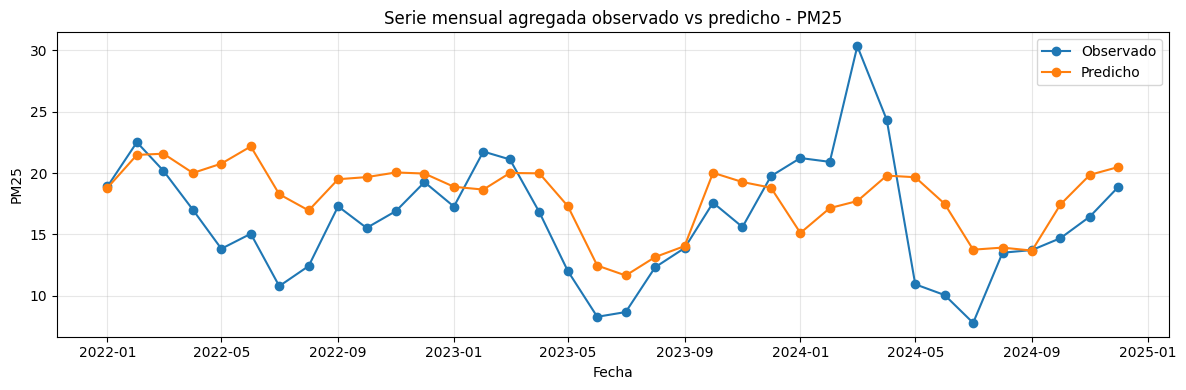

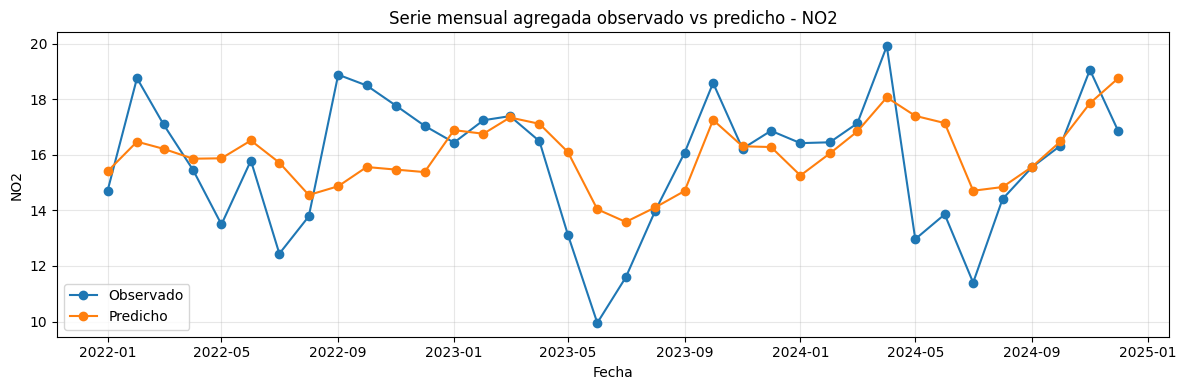

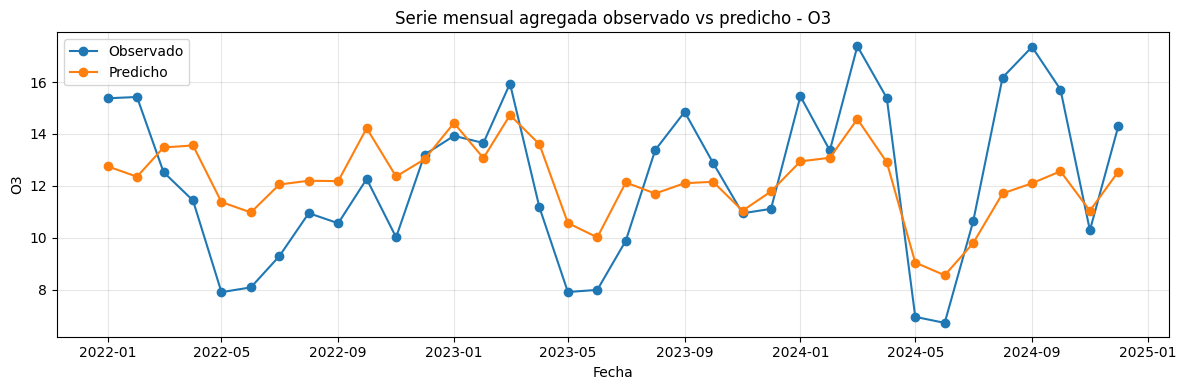

In [22]:
# %%
import matplotlib.pyplot as plt

for poll, obj in data.items():
    df = obj["df"].copy()
    obs_col = obj["obs_col"]

    monthly = (
        df.groupby("fecha")[[obs_col, "p50_hbm"]]
        .mean()
        .reset_index()
        .sort_values("fecha")
    )

    plt.figure(figsize=(12, 4))
    plt.plot(monthly["fecha"], monthly[obs_col], marker="o", label="Observado")
    plt.plot(monthly["fecha"], monthly["p50_hbm"], marker="o", label="Predicho")
    plt.title(f"Serie mensual agregada observado vs predicho - {poll}")
    plt.xlabel("Fecha")
    plt.ylabel(poll)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

 # CELDA E — Serie observado vs predicho por estación

 ## Objetivo
 Revisar cómo captura el patrón temporal en estaciones concretas.

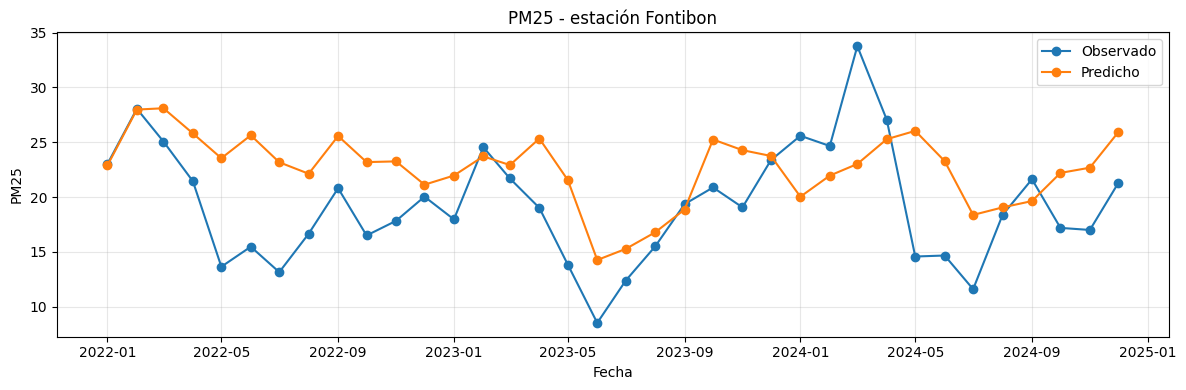

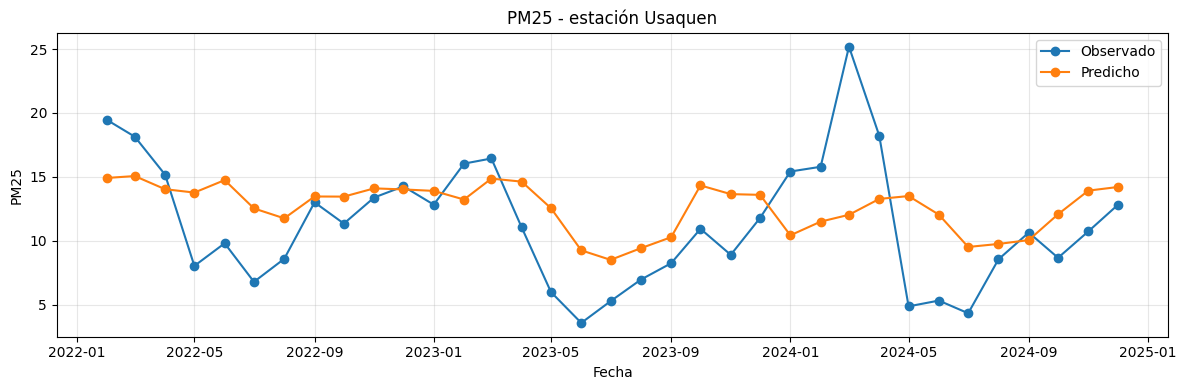

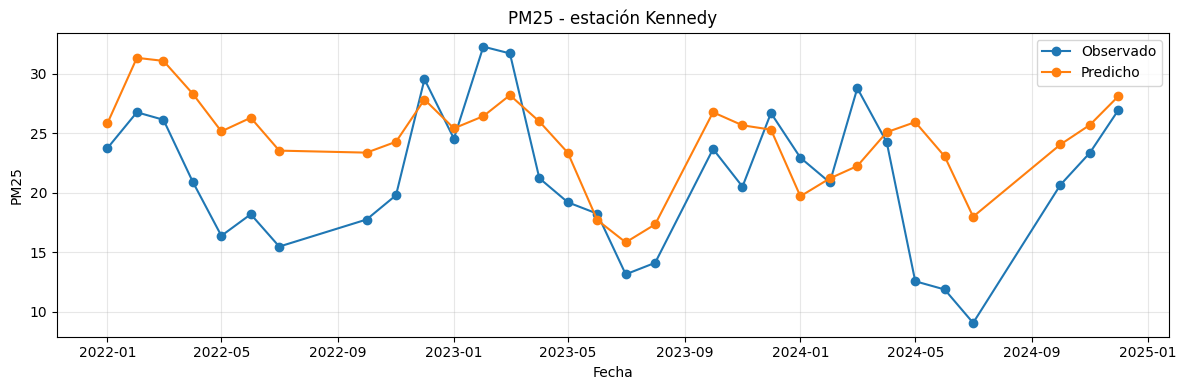

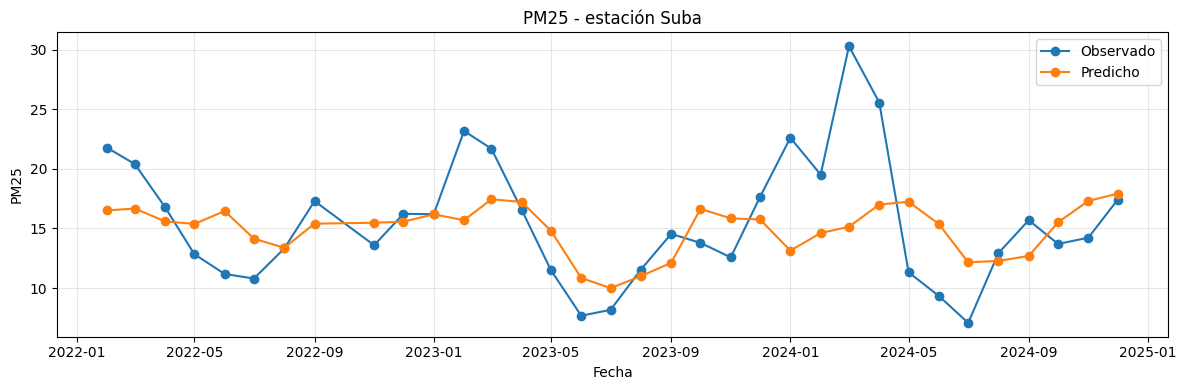

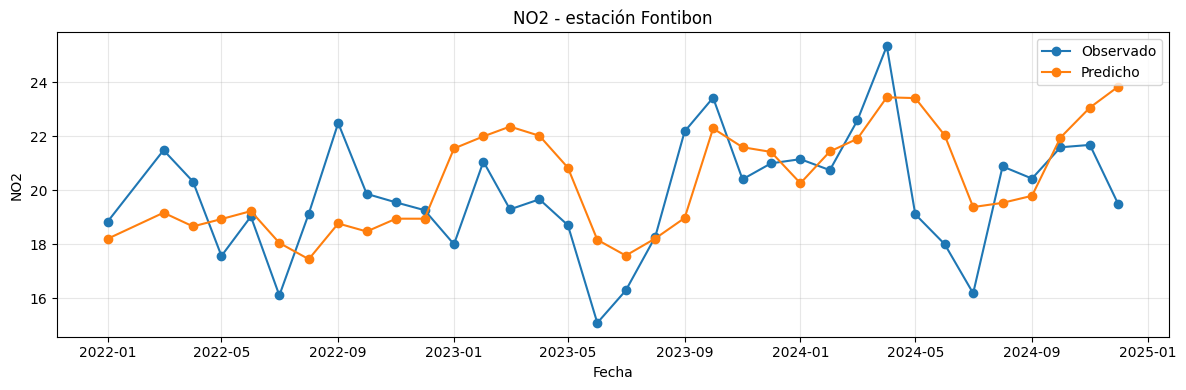

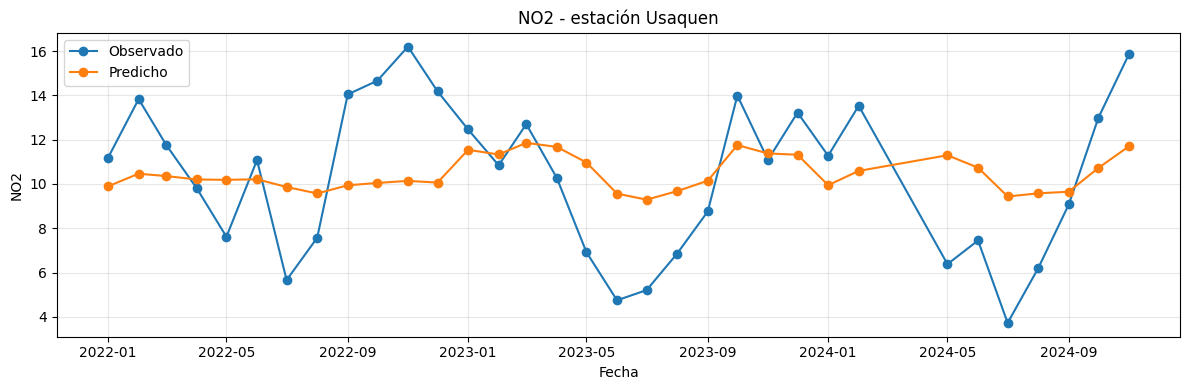

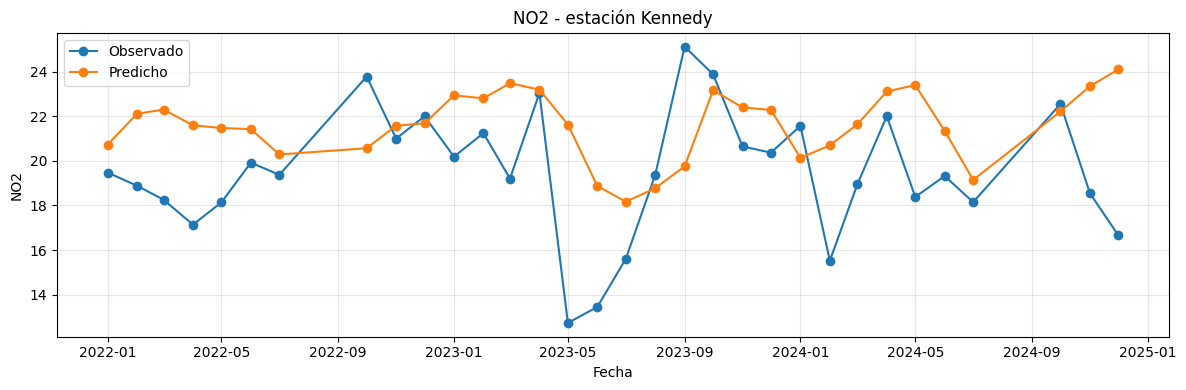

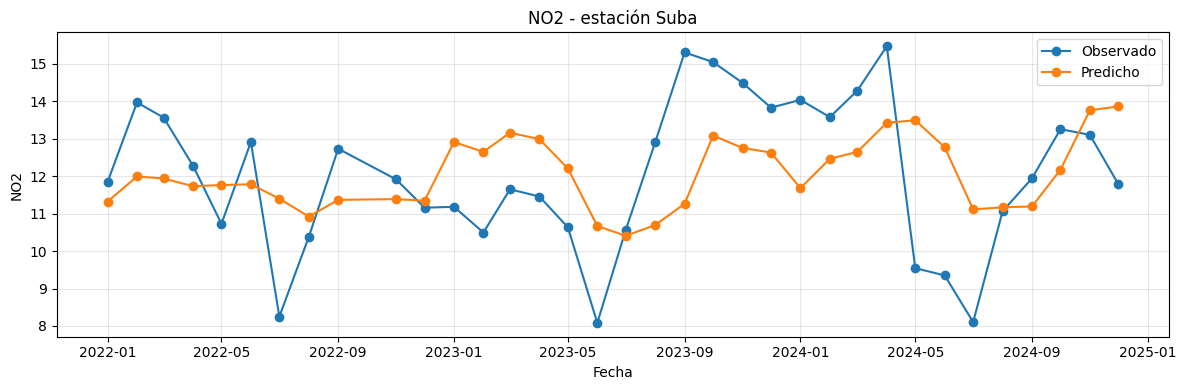

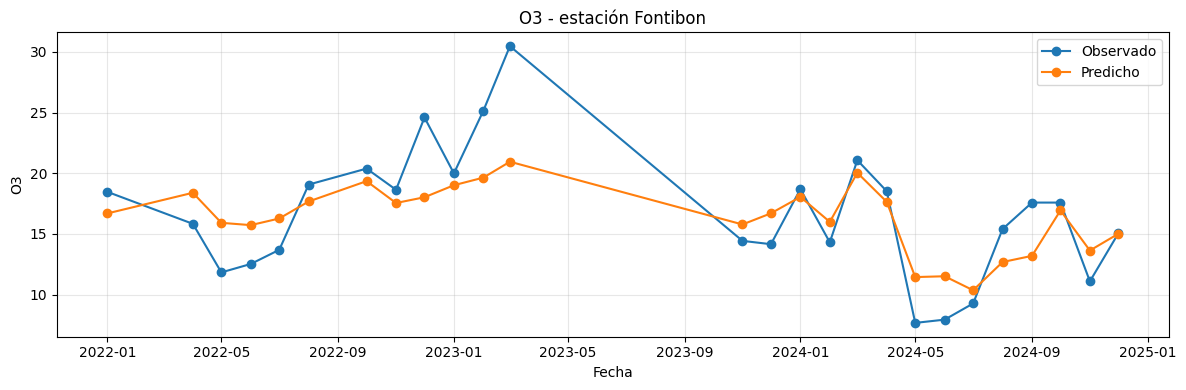

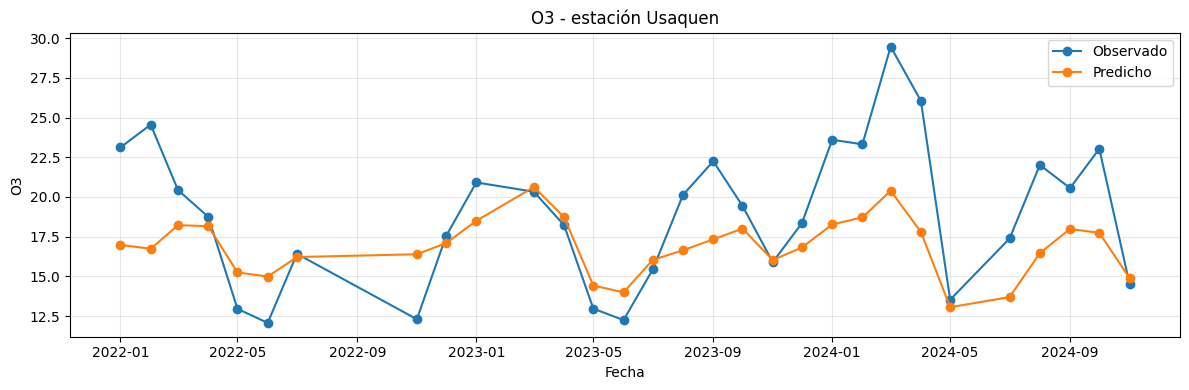

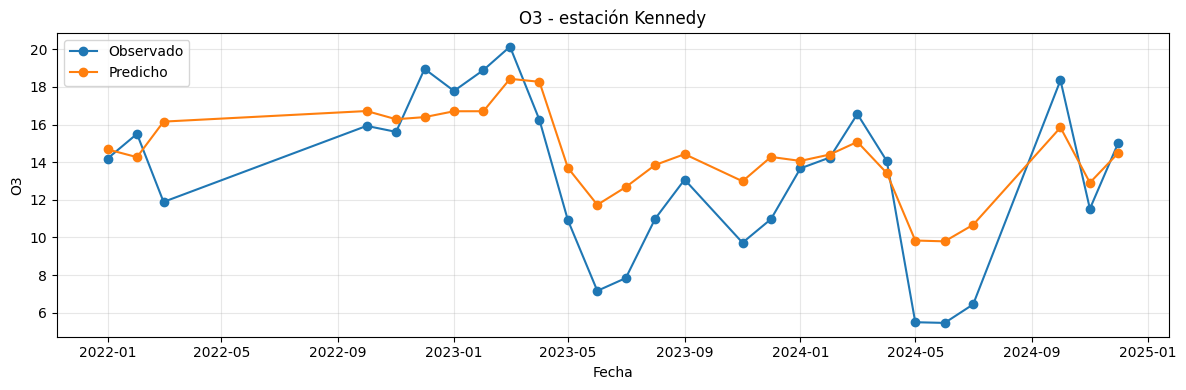

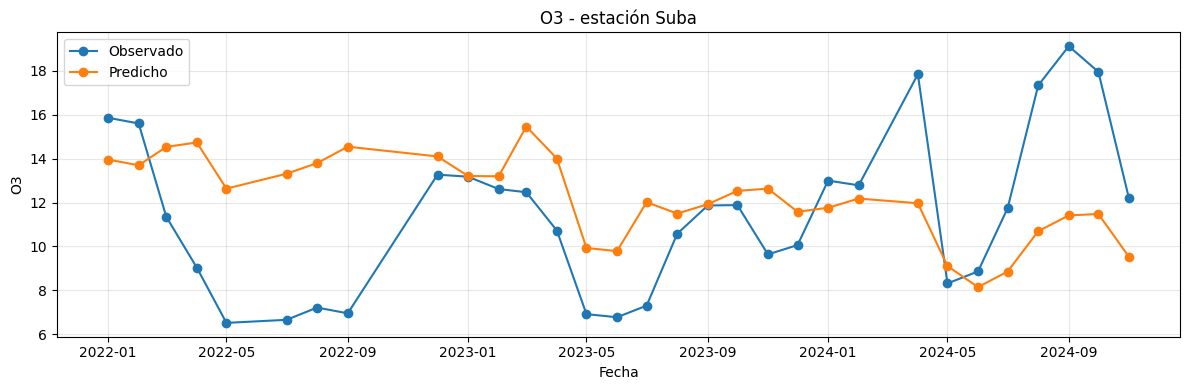

In [23]:
# %%
STATIONS_TO_CHECK = ["Fontibon", "Usaquen", "Kennedy", "Suba"]

for poll, obj in data.items():
    df = obj["df"].copy()
    obs_col = obj["obs_col"]

    for st in STATIONS_TO_CHECK:
        if st not in df["Estacion"].unique():
            continue

        tmp = (
            df.loc[df["Estacion"] == st, ["fecha", obs_col, "p50_hbm"]]
            .sort_values("fecha")
            .copy()
        )

        plt.figure(figsize=(12, 4))
        plt.plot(tmp["fecha"], tmp[obs_col], marker="o", label="Observado")
        plt.plot(tmp["fecha"], tmp["p50_hbm"], marker="o", label="Predicho")
        plt.title(f"{poll} - estación {st}")
        plt.xlabel("Fecha")
        plt.ylabel(poll)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


 # CELDA F — Scatter observado vs predicho

 ## Objetivo
 Ver la relación global entre observaciones y predicciones.

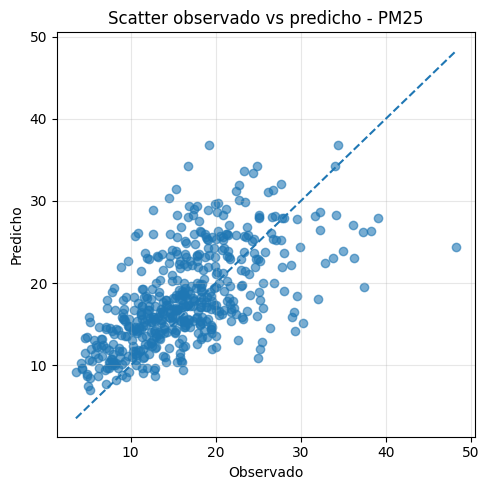

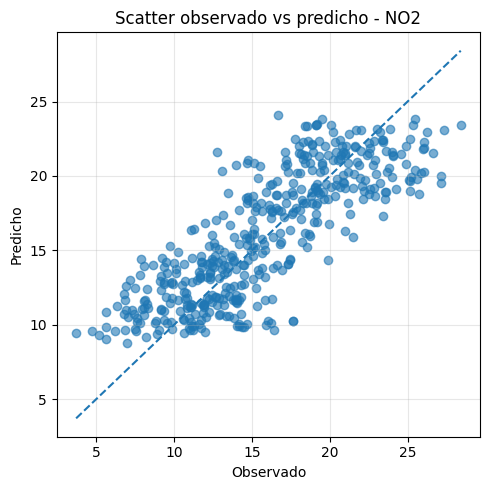

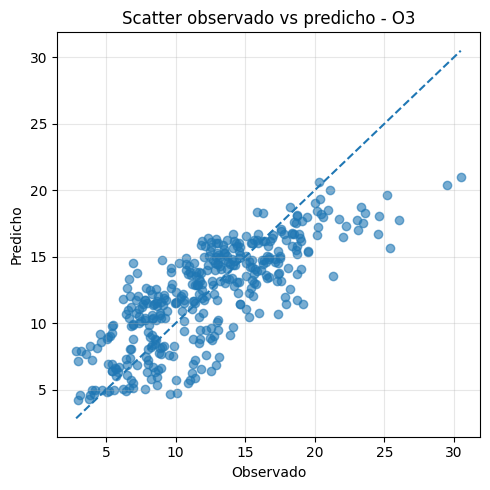

In [24]:
# %%
for poll, obj in data.items():
    df = obj["df"].copy()
    obs_col = obj["obs_col"]

    x = df[obs_col].values
    y = df["p50_hbm"].values

    lim_min = float(np.nanmin([x.min(), y.min()]))
    lim_max = float(np.nanmax([x.max(), y.max()]))

    plt.figure(figsize=(5, 5))
    plt.scatter(x, y, alpha=0.6)
    plt.plot([lim_min, lim_max], [lim_min, lim_max], linestyle="--")
    plt.title(f"Scatter observado vs predicho - {poll}")
    plt.xlabel("Observado")
    plt.ylabel("Predicho")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

 # CELDA G — Resumen comparativo de métricas

 ## Objetivo
 Calcular métricas comparables entre PM2.5, NO2 y O3
 sin usar R2 como criterio principal.

 ## Métricas incluidas
 - MAE
 - MedAE
 - RMSE
 - Bias
 - r
 - Coverage 90%
 - Width 90 mean
 - WIS 90

In [25]:
# %%
summary_rows = []

for poll, obj in data.items():
    df = obj["df"].copy()
    obs_col = obj["obs_col"]

    y = df[obs_col].to_numpy(dtype=float)
    p50 = df["p50_hbm"].to_numpy(dtype=float)
    p05 = df["p05_hbm"].to_numpy(dtype=float)
    p95 = df["p95_hbm"].to_numpy(dtype=float)

    err = p50 - y
    abs_err = np.abs(err)

    mae = np.mean(abs_err)
    medae = np.median(abs_err)
    rmse = np.sqrt(np.mean(err**2))
    bias = np.mean(err)

    if np.std(y) == 0 or np.std(p50) == 0:
        r = np.nan
    else:
        r = np.corrcoef(y, p50)[0, 1]

    coverage_90 = np.mean((y >= p05) & (y <= p95))
    width_90_mean = np.mean(p95 - p05)

    alpha = 0.10
    wis_90 = np.mean(
        (p95 - p05)
        + (2 / alpha) * (p05 - y) * (y < p05)
        + (2 / alpha) * (y - p95) * (y > p95)
    )

    summary_rows.append({
        "contaminante": poll,
        "n": len(df),
        "mae": mae,
        "medae": medae,
        "rmse": rmse,
        "bias": bias,
        "r": r,
        "coverage_90": coverage_90,
        "width_90_mean": width_90_mean,
        "wis_90": wis_90,
    })

summary_df = pd.DataFrame(summary_rows)

# opcional: ordenar columnas
summary_df = summary_df[
    [
        "contaminante",
        "n",
        "mae",
        "medae",
        "rmse",
        "bias",
        "r",
        "coverage_90",
        "width_90_mean",
        "wis_90",
    ]
]

display(summary_df)

,contaminante,n,mae,medae,rmse,bias,r,coverage_90,width_90_mean,wis_90
0,PM25,510,4.595459,3.579054,5.895033,1.779545,0.611118,0.941176,39.669529,41.724453
1,NO2,453,2.433614,2.044945,2.999565,0.306289,0.812803,0.977925,19.993583,20.435950
2,O3,384,2.493604,2.120453,3.088840,-0.116507,0.783061,0.932292,15.337768,16.691509


# insumos finales

In [26]:
from pathlib import Path
import shutil
import json
import pandas as pd

ROOT = Path(r"d:\TRABAJO DE GRADO BEN-MAP")
CODIGO = ROOT / "CODIGO"
DEST_ROOT = ROOT / "SALIDAS_SENSIBILIDAD" / "01_insumos_finales_hbm"

CONFIG = {
    "PM25": {
        "src": CODIGO / "HBM_PM25_V2_OUT",
        "prefix": "HBM_PM25_M1bclean",
        "modelo_final": "M1bclean",
    },
    "NO2": {
        "src": CODIGO / "HBM_NO2_V2_OUT",
        "prefix": "HBM_NO2_M1bclean",
        "modelo_final": "M1bclean",
    },
    "O3": {
        "src": CODIGO / "HBM_O3_V3_SEASON_OUT",
        "prefix": "HBM_O3_season",
        "modelo_final": "season",
    },
}

def ensure_dirs(base: Path):
    subdirs = {
        "modelo": base / "01_modelo_final",
        "superficies": base / "02_superficies",
        "validacion": base / "03_validacion",
        "metadata": base / "04_metadata",
    }
    for d in subdirs.values():
        d.mkdir(parents=True, exist_ok=True)
    return subdirs

def safe_copy(src: Path, dst: Path):
    if src.exists():
        shutil.copy2(src, dst)
        return True
    return False

manifest_rows = []

for poll, cfg in CONFIG.items():
    src_dir = cfg["src"]
    prefix = cfg["prefix"]
    out_dir = DEST_ROOT / poll
    dirs = ensure_dirs(out_dir)

    copied = []

    # modelo final
    for name in [
        f"{prefix}_final_posterior.nc",
        f"{prefix}_final_summary.csv",
        f"{prefix}_final_diagnostics.csv",
        f"{prefix}_final_scale_params.json",
    ]:
        src = src_dir / name
        dst = dirs["modelo"] / name
        if safe_copy(src, dst):
            copied.append(str(dst))

    # superficies
    for name in [
        f"{prefix}_surface_final.csv",
        f"{prefix}_surface_annual_summary.csv",
    ]:
        src = src_dir / name
        dst = dirs["superficies"] / name
        if safe_copy(src, dst):
            copied.append(str(dst))

    # validación
    for name in [
        f"{prefix}_metrics_folds.csv",
        f"{prefix}_pred_test_all_folds.csv",
    ]:
        src = src_dir / name
        dst = dirs["validacion"] / name
        if safe_copy(src, dst):
            copied.append(str(dst))

    # folds individuales y summaries por fold
    for pattern in [
        f"{prefix}_fold_*_pred_test.csv",
        f"{prefix}_fold_*_summary.csv",
        f"{prefix}_fold_*_scale_params.json",
    ]:
        for src in src_dir.glob(pattern):
            dst = dirs["validacion"] / src.name
            shutil.copy2(src, dst)
            copied.append(str(dst))

    # metadata
    manifest = {
        "contaminante": poll,
        "modelo_final": cfg["modelo_final"],
        "carpeta_origen": str(src_dir),
        "prefijo_archivos": prefix,
        "archivos_copiados": copied,
    }

    manifest_path = dirs["metadata"] / f"{poll}_manifest.json"
    with open(manifest_path, "w", encoding="utf-8") as f:
        json.dump(manifest, f, ensure_ascii=False, indent=2)

    manifest_rows.append({
        "contaminante": poll,
        "modelo_final": cfg["modelo_final"],
        "origen": str(src_dir),
        "destino": str(out_dir),
        "n_archivos": len(copied),
    })

summary_df = pd.DataFrame(manifest_rows)
summary_path = DEST_ROOT / "resumen_insumos_finales_hbm.csv"
summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")

print("Estructura creada y archivos copiados.")
print("Resumen:", summary_path)
print(summary_df)

Estructura creada y archivos copiados.
Resumen: d:\TRABAJO DE GRADO BEN-MAP\SALIDAS_SENSIBILIDAD\01_insumos_finales_hbm\resumen_insumos_finales_hbm.csv
  contaminante modelo_final  \
0         PM25     M1bclean   
1          NO2     M1bclean   
2           O3       season   

                                              origen  \
0  d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_PM25_V2...   
1  d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_NO2_V2_OUT   
2  d:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V3_S...   

                                             destino  n_archivos  
0  d:\TRABAJO DE GRADO BEN-MAP\SALIDAS_SENSIBILID...          16  
1  d:\TRABAJO DE GRADO BEN-MAP\SALIDAS_SENSIBILID...          16  
2  d:\TRABAJO DE GRADO BEN-MAP\SALIDAS_SENSIBILID...          17  


In [ ]:
from pathlib import Path
import pandas as pd

DEST_ROOT = Path(r"d:\TRABAJO DE GRADO BEN-MAP\SALIDAS_SENSIBILIDAD\01_insumos_finales_hbm")

SURFACE_FILES = {
    "PM25": DEST_ROOT / "PM25" / "02_superficies" / "HBM_PM25_M1bclean_surface_final.csv",
    "NO2":  DEST_ROOT / "NO2"  / "02_superficies" / "HBM_NO2_M1bclean_surface_final.csv",
    "O3":   DEST_ROOT / "O3"   / "02_superficies" / "HBM_O3_season_surface_final.csv",
}

for poll, path in SURFACE_FILES.items():
    if not path.exists():
        print(f"[{poll}] No existe la superficie final: {path}")
        continue

    df = pd.read_csv(path, parse_dates=["fecha"])

    base_cols = ["cell_id", "fecha", "year", "month"]
    if "month_of_year" in df.columns:
        base_cols.append("month_of_year")
    if "cell_idx" in df.columns:
        base_cols.append("cell_idx")
    if "time_idx" in df.columns:
        base_cols.append("time_idx")

    out_dir = path.parent

    p05 = df[base_cols + ["p05_hbm"]].rename(columns={"p05_hbm": "conc_hbm"})
    p50 = df[base_cols + ["p50_hbm"]].rename(columns={"p50_hbm": "conc_hbm"})
    p95 = df[base_cols + ["p95_hbm"]].rename(columns={"p95_hbm": "conc_hbm"})

    p05.to_csv(out_dir / f"{poll}_surface_P05.csv", index=False, encoding="utf-8-sig")
    p50.to_csv(out_dir / f"{poll}_surface_P50.csv", index=False, encoding="utf-8-sig")
    p95.to_csv(out_dir / f"{poll}_surface_P95.csv", index=False, encoding="utf-8-sig")

    print(f"[{poll}] Exportados P05, P50 y P95 en {out_dir}")

[PM25] Exportados P05, P50 y P95 en d:\TRABAJO DE GRADO BEN-MAP\SALIDAS_SENSIBILIDAD\01_insumos_finales_hbm\PM25\02_superficies
[NO2] Exportados P05, P50 y P95 en d:\TRABAJO DE GRADO BEN-MAP\SALIDAS_SENSIBILIDAD\01_insumos_finales_hbm\NO2\02_superficies
[O3] Exportados P05, P50 y P95 en d:\TRABAJO DE GRADO BEN-MAP\SALIDAS_SENSIBILIDAD\01_insumos_finales_hbm\O3\02_superficies


: 